In [1]:
#  4th order Runge-Kutta
import numpy as np
import scipy.optimize as opt
import scipy.interpolate as interpol
import matplotlib.pyplot as plt
import time as time
import scipy.ndimage as scimage
import math
from sympy.parsing.mathematica import mathematica
from numpy import cos, sin, tan, roll
from scipy.interpolate import UnivariateSpline
from auxilliary_functions import *
from constants_GeV import *
from EOS import *
from TOV_initial_state import *
from metric_solver_radial_RK4 import *
from matter_and_metric_solver import *
from gravitational_observables import *
from density_pressure_functions import *
from save_data import *
from frequency_peak_functions import *

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['text.usetex'] = True


plotdirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/plots/"

In [2]:
def clean_RM_CL_data(meta_data):
    Rbound = 1.0
    for i in range(np.shape(meta_data)[0]):
        if meta_data[i, 8] <= Rbound:
            if i == 0:
                meta_data[i, 8] = meta_data[i+1, 8]
                meta_data[i, 9] = meta_data[i+1, 9]
                meta_data[i, 10] = meta_data[i+1, 10]
                meta_data[i, 11] = meta_data[i+1, 11]
            elif i == np.shape(meta_data)[0]-1:
                meta_data[i, 8] = meta_data[i-1, 8]
                meta_data[i, 9] = meta_data[i-1, 9]
                meta_data[i, 10] = meta_data[i-1, 10]
                meta_data[i, 11] = meta_data[i-1, 11]
            else:
                meta_data[i, 8] = (meta_data[i-1, 8] + meta_data[i+1, 8]) / 2.0
                meta_data[i, 9] = (meta_data[i-1, 9] + meta_data[i+1, 9]) / 2.0
                meta_data[i, 10] = (meta_data[i-1, 10] + meta_data[i+1, 10]) / 2.0
                meta_data[i, 11] = (meta_data[i-1, 11] + meta_data[i+1, 11]) / 2.0
    
    for i in range(np.shape(meta_data)[0]):
        if meta_data[i, 4] <= Rbound:
            if i == 0:
                meta_data[i, 4] = meta_data[i+1, 4]
                meta_data[i, 5] = meta_data[i+1, 5]
                meta_data[i, 6] = meta_data[i+1, 6]
                meta_data[i, 7] = meta_data[i+1, 7]
            elif i == np.shape(meta_data)[0]-1:
                meta_data[i, 4] = meta_data[i-1, 4]
                meta_data[i, 5] = meta_data[i-1, 5]
                meta_data[i, 6] = meta_data[i-1, 6]
                meta_data[i, 7] = meta_data[i-1, 7]
            else:
                meta_data[i, 4] = (meta_data[i-1, 4] + meta_data[i+1, 4]) / 2.0
                meta_data[i, 5] = (meta_data[i-1, 5] + meta_data[i+1, 5]) / 2.0
                meta_data[i, 6] = (meta_data[i-1, 6] + meta_data[i+1, 6]) / 2.0
                meta_data[i, 7] = (meta_data[i-1, 7] + meta_data[i+1, 7]) / 2.0
                
    return meta_data;

In [35]:
# meta_data_eps1e1_fa1e16 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/campus_cluster/MRCL_eps1e-1_fa1e16.npy")
# meta_data_eps1e1_fa1e15 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/delta/MRCL_eps1e-1_fa1e15.npy")
# meta_data_eps1e3_fa1e16 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/campus_cluster/MRCL_eps1e-3_fa1e16.npy")
# meta_data_eps1e3_fa1e15 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/campus_cluster/MRCL_eps1e-3_fa1e15.npy")
#MRCL_KEandMasscut_eps1

meta_data_eps1e1_fa1e16 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/MRCL_KEcut_eps1e-1_fa1e16.npy")
meta_data_eps1e1_fa1e15 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/MRCL_KEcut_eps1e-1_fa1e15.npy")
meta_data_eps1e1_fa1e14 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/MRCL_KEcut_eps1e-1_fa1e14.npy")

meta_data_eps1e3_fa1e16 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/MRCL_KEcut_eps1e-3_fa1e16.npy")
meta_data_eps1e3_fa1e15 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/MRCL_KEcut_eps1e-3_fa1e15.npy")
meta_data_eps1e3_fa1e14 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/MRCL_KEcut_eps1e-3_fa1e14.npy")

meta_data_eps1e6_fa1e16 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/MRCL_KEcut_eps1e-6_fa1e16.npy")
meta_data_eps1e6_fa1e15 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/MRCL_KEcut_eps1e-6_fa1e15.npy")
meta_data_eps1e6_fa1e14 = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/MRCL_KEcut_eps1e-6_fa1e14.npy")



In [36]:
meta_data_eps1e1_fa1e16 = clean_RM_CL_data(meta_data_eps1e1_fa1e16)
meta_data_eps1e1_fa1e15 = clean_RM_CL_data(meta_data_eps1e1_fa1e15)
meta_data_eps1e1_fa1e14 = clean_RM_CL_data(meta_data_eps1e1_fa1e14)

meta_data_eps1e3_fa1e16 = clean_RM_CL_data(meta_data_eps1e3_fa1e16)
meta_data_eps1e3_fa1e15 = clean_RM_CL_data(meta_data_eps1e3_fa1e15)
meta_data_eps1e3_fa1e14 = clean_RM_CL_data(meta_data_eps1e3_fa1e14)

meta_data_eps1e6_fa1e16 = clean_RM_CL_data(meta_data_eps1e6_fa1e16)
meta_data_eps1e6_fa1e15 = clean_RM_CL_data(meta_data_eps1e6_fa1e15)
meta_data_eps1e6_fa1e14 = clean_RM_CL_data(meta_data_eps1e6_fa1e14)



# Mass-Radius Curves

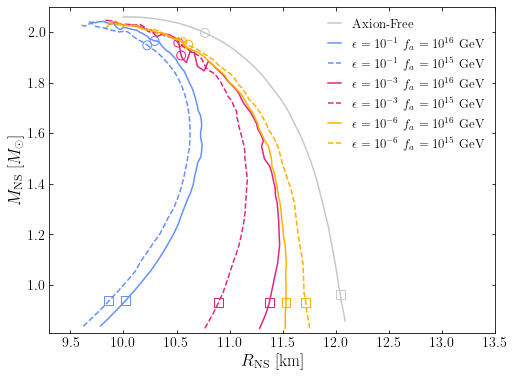

In [38]:
labelfontsize = 17
legendfontsize = 13
tickfontsize = 14
mks = 2

start1, end1 = 18, -5
start2, end2 = 18, -5
start3, end3 = 18, -5
start4, end4 = 18, -5
start5, end5 = 18, -5
start6, end6 = 18, -5
start_TOV, end_TOV = 18, -5
sn = 2

boxindex = 3
circindex = -27
circTOV = -27
boxTOV = 3


# make the plots all fancy nice
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8, 6), gridspec_kw={'hspace':0.03, 'wspace':0.15})

ax.plot(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 4], sn), smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 5], sn), '-', markersize=mks, color=colors[5], label=r'Axion-Free')
ax.plot(smooth(meta_data_eps1e1_fa1e16[start1:end1, 8], sn), smooth(meta_data_eps1e1_fa1e16[start1:end1, 9], sn), '-', markersize=mks, color=colors[0], label=r'$\epsilon = 10^{-1} \ f_a = 10^{16}~\mathrm{GeV}$')
ax.plot(smooth(meta_data_eps1e1_fa1e15[start2:end2, 8], sn), smooth(meta_data_eps1e1_fa1e15[start2:end2, 9], sn), '--', markersize=mks, color=colors[0], label=r'$\epsilon = 10^{-1} \ f_a = 10^{15}~\mathrm{GeV}$')
#ax.plot(smooth(meta_data_eps1e1_fa1e14[start2:end2, 8], 4), smooth(meta_data_eps1e1_fa1e14[start2:end2, 9], 4), '-.', markersize=mks, color=colors[0], label=r'$\epsilon = 10^{-1} \ f_a = 10^{14}~\mathrm{GeV}$')

ax.plot(smooth(meta_data_eps1e3_fa1e16[start3:end3, 8], sn), smooth(meta_data_eps1e3_fa1e16[start3:end3, 9], sn), '-', markersize=mks, color=colors[2], label=r'$\epsilon = 10^{-3} \ f_a = 10^{16}~\mathrm{GeV}$')
ax.plot(smooth(meta_data_eps1e3_fa1e15[start4:end4, 8], sn), smooth(meta_data_eps1e3_fa1e15[start4:end4, 9], sn), '--', markersize=mks, color=colors[2], label=r'$\epsilon = 10^{-3} \ f_a = 10^{15}~\mathrm{GeV}$')
#ax.plot(smooth(meta_data_eps1e3_fa1e14[start4:end4, 8], sn), smooth(meta_data_eps1e3_fa1e14[start4:end4, 9], sn), '-.', markersize=mks, color=colors[2], label=r'$\epsilon = 10^{-3} \ f_a = 10^{14}~\mathrm{GeV}$')

ax.plot(smooth(meta_data_eps1e6_fa1e16[start5:end5, 8], sn), smooth(meta_data_eps1e6_fa1e16[start5:end5, 9], sn), '-', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{16}~\mathrm{GeV}$')
ax.plot(smooth(meta_data_eps1e6_fa1e15[start6:end6, 8], sn), smooth(meta_data_eps1e6_fa1e15[start6:end6, 9], sn), '--', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{15}~\mathrm{GeV}$')
#ax.plot(smooth(meta_data_eps1e6_fa1e14[start6:end6, 8], sn), smooth(meta_data_eps1e6_fa1e14[start6:end6, 9], sn), '-.', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{14}~\mathrm{GeV}$')


ax.scatter(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 4], sn)[boxTOV], smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 5], sn)[boxTOV], s=80, facecolors='none', edgecolor=colors[5], marker='s')
ax.scatter(smooth(meta_data_eps1e1_fa1e16[start1:end1, 8], sn)[boxindex], smooth(meta_data_eps1e1_fa1e16[start1:end1, 9], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[0], marker='s')
ax.scatter(smooth(meta_data_eps1e1_fa1e15[start2:end2, 8], 4)[boxindex], smooth(meta_data_eps1e1_fa1e15[start2:end2, 9], 4)[boxindex], s=80, facecolors='none', edgecolor=colors[0], marker='s')
ax.scatter(smooth(meta_data_eps1e3_fa1e16[start3:end3, 8], sn)[boxindex], smooth(meta_data_eps1e3_fa1e16[start3:end3, 9], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[2], marker='s')
ax.scatter(smooth(meta_data_eps1e3_fa1e15[start4:end4, 8], sn)[boxindex], smooth(meta_data_eps1e3_fa1e15[start4:end4, 9], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[2], marker='s')
ax.scatter(smooth(meta_data_eps1e6_fa1e16[start5:end5, 8], sn)[boxindex], smooth(meta_data_eps1e6_fa1e16[start5:end5, 9], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')
ax.scatter(smooth(meta_data_eps1e6_fa1e15[start6:end6, 8], sn)[boxindex], smooth(meta_data_eps1e6_fa1e15[start6:end6, 9], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')
#ax.scatter(smooth(meta_data_eps1e6_fa1e14[start6:end6, 8], sn)[boxindex], smooth(meta_data_eps1e6_fa1e14[start6:end6, 9], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')

ax.scatter(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 4], sn)[circTOV], smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 5], sn)[circTOV], s=80, facecolors='none', edgecolor=colors[5])
ax.scatter(smooth(meta_data_eps1e1_fa1e16[start1:end1, 8], sn)[circindex], smooth(meta_data_eps1e1_fa1e16[start1:end1, 9], sn)[circindex], s=80, facecolors='none', edgecolor=colors[0])
ax.scatter(smooth(meta_data_eps1e1_fa1e15[start2:end2, 8], 4)[circindex], smooth(meta_data_eps1e1_fa1e15[start2:end2, 9], 4)[circindex], s=80, facecolors='none', edgecolor=colors[0])
ax.scatter(smooth(meta_data_eps1e3_fa1e16[start3:end3, 8], sn)[circindex], smooth(meta_data_eps1e3_fa1e16[start3:end3, 9], sn)[circindex], s=80, facecolors='none', edgecolor=colors[2])
ax.scatter(smooth(meta_data_eps1e3_fa1e15[start4:end4, 8], sn)[circindex], smooth(meta_data_eps1e3_fa1e15[start4:end4, 9], sn)[circindex], s=80, facecolors='none', edgecolor=colors[2])
ax.scatter(smooth(meta_data_eps1e6_fa1e16[start5:end5, 8], sn)[circindex], smooth(meta_data_eps1e6_fa1e16[start5:end5, 9], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])
ax.scatter(smooth(meta_data_eps1e6_fa1e15[start6:end6, 8], sn)[circindex], smooth(meta_data_eps1e6_fa1e15[start6:end6, 9], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])
#ax.scatter(smooth(meta_data_eps1e6_fa1e14[start6:end6, 8], sn)[circindex], smooth(meta_data_eps1e6_fa1e14[start6:end6, 9], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])

ax.set_ylabel(r'$M_{\rm NS}$ [$M_{\odot}$]', fontname="serif", fontsize=labelfontsize)
ax.set_xlabel(r'$R_{\rm NS}$ [km]', fontname="serif", fontsize=labelfontsize)
ax.tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax.legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)
ax.set_xlim(9.3, 13.5)
ax.set_ylim(0.81, 2.1)

#plt.savefig(plotdirectory + "MR.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [53]:
print(meta_data_eps1e1_fa1e16[boxindex, 0])
print(meta_data_eps1e1_fa1e16[circindex, 0])

0.001480821074377156
0.007527507128083876


In [1294]:
meta_data_eps1e6_fa1e14[0]

array([1.22167739e-03, 1.00000000e-06, 1.00000000e+14, 5.64776375e-20,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

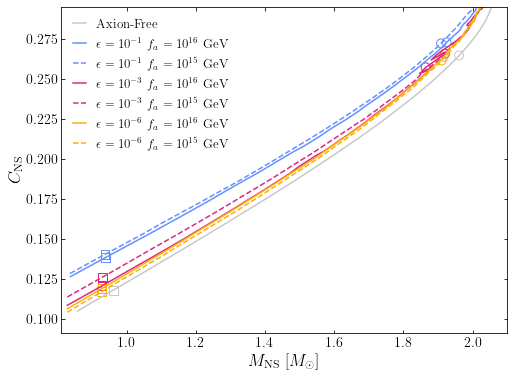

In [1297]:
labelfontsize = 17
legendfontsize = 13
tickfontsize = 14
mks = 2

start1, end1 = 18, -10
start2, end2 = 18, -10
start3, end3 = 18, -10
start4, end4 = 18, -10
start5, end5 = 18, -10
start6, end6 = 18, -10
start_TOV, end_TOV = 18, -10
sn = 3

boxindex = 3
circindex = -27
circTOV = -27
boxTOV = 3


# make the plots all fancy nice
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8, 6), gridspec_kw={'hspace':0.03, 'wspace':0.15})

ax.plot(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 5], sn), smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], sn), '-', markersize=mks, color=colors[5], label=r'Axion-Free')
ax.plot(smooth(meta_data_eps1e1_fa1e16[start1:end1, 9], sn), smooth(meta_data_eps1e1_fa1e16[start1:end1, 10], sn), '-', markersize=mks, color=colors[0], label=r'$\epsilon = 10^{-1} \ f_a = 10^{16}~\mathrm{GeV}$')
ax.plot(smooth(meta_data_eps1e1_fa1e15[start2:end2, 9], sn), smooth(meta_data_eps1e1_fa1e15[start2:end2, 10], sn), '--', markersize=mks, color=colors[0], label=r'$\epsilon = 10^{-1} \ f_a = 10^{15}~\mathrm{GeV}$')
#ax.plot(smooth(meta_data_eps1e1_fa1e14[start2:end2, 8], 4), smooth(meta_data_eps1e1_fa1e14[start2:end2, 9], 4), '-.', markersize=mks, color=colors[0], label=r'$\epsilon = 10^{-1} \ f_a = 10^{14}~\mathrm{GeV}$')

ax.plot(smooth(meta_data_eps1e3_fa1e16[start3:end3, 9], sn), smooth(meta_data_eps1e3_fa1e16[start3:end3, 10], sn), '-', markersize=mks, color=colors[2], label=r'$\epsilon = 10^{-3} \ f_a = 10^{16}~\mathrm{GeV}$')
ax.plot(smooth(meta_data_eps1e3_fa1e15[start4:end4, 9], sn), smooth(meta_data_eps1e3_fa1e15[start4:end4, 10], sn), '--', markersize=mks, color=colors[2], label=r'$\epsilon = 10^{-3} \ f_a = 10^{15}~\mathrm{GeV}$')
#ax.plot(smooth(meta_data_eps1e3_fa1e14[start4:end4, 8], sn), smooth(meta_data_eps1e3_fa1e14[start4:end4, 9], sn), '-.', markersize=mks, color=colors[2], label=r'$\epsilon = 10^{-3} \ f_a = 10^{14}~\mathrm{GeV}$')

ax.plot(smooth(meta_data_eps1e6_fa1e16[start5:end5, 9], sn), smooth(meta_data_eps1e6_fa1e16[start5:end5, 10], sn), '-', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{16}~\mathrm{GeV}$')
ax.plot(smooth(meta_data_eps1e6_fa1e15[start6:end6, 9], sn), smooth(meta_data_eps1e6_fa1e15[start6:end6, 10], sn), '--', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{15}~\mathrm{GeV}$')
#ax.plot(smooth(meta_data_eps1e6_fa1e14[start6:end6, 9], sn), smooth(meta_data_eps1e6_fa1e14[start6:end6, 10], sn), '-.', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{14}~\mathrm{GeV}$')


ax.scatter(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 5], sn)[boxTOV], smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], sn)[boxTOV], s=80, facecolors='none', edgecolor=colors[5], marker='s')
ax.scatter(smooth(meta_data_eps1e1_fa1e16[start1:end1, 9], sn)[boxindex], smooth(meta_data_eps1e1_fa1e16[start1:end1, 10], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[0], marker='s')
ax.scatter(smooth(meta_data_eps1e1_fa1e15[start2:end2, 9], sn)[boxindex], smooth(meta_data_eps1e1_fa1e15[start2:end2, 10], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[0], marker='s')
ax.scatter(smooth(meta_data_eps1e3_fa1e16[start3:end3, 9], sn)[boxindex], smooth(meta_data_eps1e3_fa1e16[start3:end3, 10], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[2], marker='s')
ax.scatter(smooth(meta_data_eps1e3_fa1e15[start4:end4, 9], sn)[boxindex], smooth(meta_data_eps1e3_fa1e15[start4:end4, 10], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[2], marker='s')
ax.scatter(smooth(meta_data_eps1e6_fa1e16[start5:end5, 9], sn)[boxindex], smooth(meta_data_eps1e6_fa1e16[start5:end5, 10], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')
ax.scatter(smooth(meta_data_eps1e6_fa1e15[start6:end6, 9], sn)[boxindex], smooth(meta_data_eps1e6_fa1e15[start6:end6, 10], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')
#ax.scatter(smooth(meta_data_eps1e6_fa1e14[start6:end6, 9], sn)[boxindex], smooth(meta_data_eps1e6_fa1e14[start6:end6, 10], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')

ax.scatter(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 5], sn)[circTOV], smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], sn)[circTOV], s=80, facecolors='none', edgecolor=colors[5])
ax.scatter(smooth(meta_data_eps1e1_fa1e16[start1:end1, 9], sn)[circindex], smooth(meta_data_eps1e1_fa1e16[start1:end1, 10], sn)[circindex], s=80, facecolors='none', edgecolor=colors[0])
ax.scatter(smooth(meta_data_eps1e1_fa1e15[start2:end2, 9], sn)[circindex], smooth(meta_data_eps1e1_fa1e15[start2:end2, 10], sn)[circindex], s=80, facecolors='none', edgecolor=colors[0])
ax.scatter(smooth(meta_data_eps1e3_fa1e16[start3:end3, 9], sn)[circindex], smooth(meta_data_eps1e3_fa1e16[start3:end3, 10], sn)[circindex], s=80, facecolors='none', edgecolor=colors[2])
ax.scatter(smooth(meta_data_eps1e3_fa1e15[start4:end4, 9], sn)[circindex], smooth(meta_data_eps1e3_fa1e15[start4:end4, 10], sn)[circindex], s=80, facecolors='none', edgecolor=colors[2])
ax.scatter(smooth(meta_data_eps1e6_fa1e16[start5:end5, 9], sn)[circindex], smooth(meta_data_eps1e6_fa1e16[start5:end5, 10], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])
ax.scatter(smooth(meta_data_eps1e6_fa1e15[start6:end6, 9], sn)[circindex], smooth(meta_data_eps1e6_fa1e15[start6:end6, 10], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])
#ax.scatter(smooth(meta_data_eps1e6_fa1e14[start6:end6, 9], sn)[circindex], smooth(meta_data_eps1e6_fa1e14[start6:end6, 10], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])

ax.set_xlabel(r'$M_{\rm NS}$ [$M_{\odot}$]', fontname="serif", fontsize=labelfontsize)
ax.set_ylabel(r'$C_{\rm NS}$ ', fontname="serif", fontsize=labelfontsize)
ax.tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax.legend(frameon=False, fontsize=legendfontsize, loc=2, handlelength=1)
ax.set_ylim(0.091, 0.295)
ax.set_xlim(0.81, 2.1)

plt.savefig(plotdirectory + "CM.pdf", format="pdf", bbox_inches="tight")

plt.show()

# $\Lambda C$ Curves

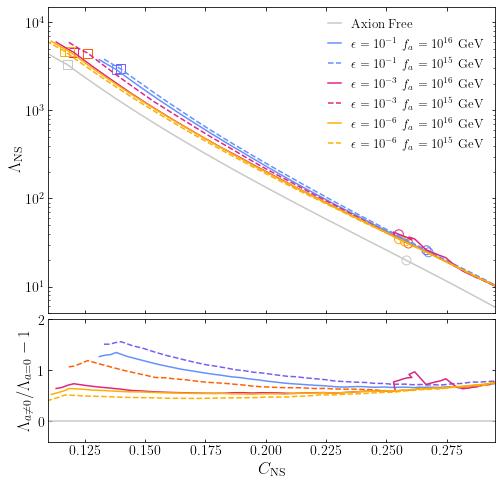

In [1302]:
labelfontsize = 17
legendfontsize = 13
tickfontsize = 14
mks = 2

start1, end1 = 18, -13
start2, end2 = 18, -13
start3, end3 = 18, -13
start4, end4 = 18, -13
start5, end5 = 18, -13
start6, end6 = 18, -13
start_TOV, end_TOV = 18, -13
sn = 7

boxindex = 3
circindex = -27
circTOV = -27
boxTOV = 3

# get differentials
# LCnoaxion_interpolating = interpol.interp1d(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 7])
LCnoaxion_interpolating = interpol.interp1d(meta_data_eps1e1_fa1e16[:, 6], meta_data_eps1e1_fa1e16[:, 7])
diffs_eps1e1_fa1e16 = 1 - smooth(meta_data_eps1e1_fa1e16[start1:end1, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e1_fa1e16[start1:end1, 10],sn))
diffs_eps1e1_fa1e15 = 1 - smooth(meta_data_eps1e1_fa1e15[start2:end2, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e1_fa1e15[start2:end2, 10],sn))

diffs_eps1e3_fa1e16 = 1 - smooth(meta_data_eps1e3_fa1e16[start3:end3, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e3_fa1e16[start3:end3, 10],sn))
diffs_eps1e3_fa1e15 = 1 - smooth(meta_data_eps1e3_fa1e15[start4:end4, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e3_fa1e15[start4:end4, 10],sn))

diffs_eps1e6_fa1e16 = 1 - smooth(meta_data_eps1e6_fa1e16[start5:end5, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e6_fa1e16[start5:end5, 10],sn))
diffs_eps1e6_fa1e15 = 1 - smooth(meta_data_eps1e6_fa1e15[start6:end6, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e6_fa1e15[start6:end6, 10],sn))
#diffs_eps1e6_fa1e14 = 1 - smooth(meta_data_eps1e6_fa1e14[start6:end6, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e6_fa1e14[start6:end6, 10],sn))


# make the plots all fancy nice
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (8, 8), gridspec_kw={'height_ratios': [5, 2], 'hspace':0.03, 'wspace':0.15})

ax[0].plot(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], sn), smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 7], sn), '-', markersize=mks, color=colors[5], label=r'Axion Free')
ax[0].plot(smooth(meta_data_eps1e1_fa1e16[start1:end1, 10], sn), smooth(meta_data_eps1e1_fa1e16[start1:end1, 11], sn), '-', markersize=mks, color=colors[0], label=r'$\epsilon = 10^{-1} \ f_a = 10^{16}~\mathrm{GeV}$')
ax[0].plot(smooth(meta_data_eps1e1_fa1e15[start2:end2, 10], sn), smooth(meta_data_eps1e1_fa1e15[start2:end2, 11], sn), '--', markersize=mks, color=colors[0], label=r'$\epsilon = 10^{-1} \ f_a = 10^{15}~\mathrm{GeV}$')

ax[0].plot(smooth(meta_data_eps1e3_fa1e16[start3:end3, 10], sn), smooth(meta_data_eps1e3_fa1e16[start3:end3, 11], sn), '-', markersize=mks, color=colors[2], label=r'$\epsilon = 10^{-3} \ f_a = 10^{16}~\mathrm{GeV}$')
ax[0].plot(smooth(meta_data_eps1e3_fa1e15[start4:end4, 10], sn), smooth(meta_data_eps1e3_fa1e15[start4:end4, 11], sn), '--', markersize=mks, color=colors[2], label=r'$\epsilon = 10^{-3} \ f_a = 10^{15}~\mathrm{GeV}$')

ax[0].plot(smooth(meta_data_eps1e6_fa1e16[start5:end5, 10], sn), smooth(meta_data_eps1e6_fa1e16[start5:end5, 11], sn), '-', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{16}~\mathrm{GeV}$')
ax[0].plot(smooth(meta_data_eps1e6_fa1e15[start6:end6, 10], sn), smooth(meta_data_eps1e6_fa1e15[start6:end6, 11], sn), '--', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{15}~\mathrm{GeV}$')
#ax[0].plot(smooth(meta_data_eps1e6_fa1e14[start6:end6, 10], sn), smooth(meta_data_eps1e6_fa1e14[start6:end6, 11], sn), '-.', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{14}~\mathrm{GeV}$')


ax[0].scatter(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], sn)[boxTOV], smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 7], sn)[boxTOV], s=80, facecolors='none', edgecolor=colors[5], marker='s')
ax[0].scatter(smooth(meta_data_eps1e1_fa1e16[start1:end1, 10], sn)[boxindex], smooth(meta_data_eps1e1_fa1e16[start1:end1, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[0], marker='s')
ax[0].scatter(smooth(meta_data_eps1e1_fa1e15[start2:end2, 10], sn)[boxindex], smooth(meta_data_eps1e1_fa1e15[start2:end2, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[1], marker='s')
ax[0].scatter(smooth(meta_data_eps1e3_fa1e16[start3:end3, 10], sn)[boxindex], smooth(meta_data_eps1e3_fa1e16[start3:end3, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[2], marker='s')
ax[0].scatter(smooth(meta_data_eps1e3_fa1e15[start4:end4, 10], sn)[boxindex], smooth(meta_data_eps1e3_fa1e15[start4:end4, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[3], marker='s')
ax[0].scatter(smooth(meta_data_eps1e6_fa1e16[start5:end5, 10], sn)[boxindex], smooth(meta_data_eps1e6_fa1e16[start5:end5, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')
ax[0].scatter(smooth(meta_data_eps1e6_fa1e15[start6:end6, 10], sn)[boxindex], smooth(meta_data_eps1e6_fa1e15[start6:end6, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')
#ax[0].scatter(smooth(meta_data_eps1e6_fa1e14[start6:end6, 10], sn)[boxindex], smooth(meta_data_eps1e6_fa1e14[start6:end6, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')

ax[0].scatter(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], sn)[circTOV], smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 7], sn)[circTOV], s=80, facecolors='none', edgecolor=colors[5])
ax[0].scatter(smooth(meta_data_eps1e1_fa1e16[start1:end1, 10], sn)[circindex], smooth(meta_data_eps1e1_fa1e16[start1:end1, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[0])
ax[0].scatter(smooth(meta_data_eps1e1_fa1e15[start2:end2, 10], sn)[circindex], smooth(meta_data_eps1e1_fa1e15[start2:end2, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[1])
ax[0].scatter(smooth(meta_data_eps1e3_fa1e16[start3:end3, 10], sn)[circindex], smooth(meta_data_eps1e3_fa1e16[start3:end3, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[2])
ax[0].scatter(smooth(meta_data_eps1e3_fa1e15[start4:end4, 10], sn)[circindex], smooth(meta_data_eps1e3_fa1e15[start4:end4, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[3])
ax[0].scatter(smooth(meta_data_eps1e6_fa1e16[start5:end5, 10], sn)[circindex], smooth(meta_data_eps1e6_fa1e16[start5:end5, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])
ax[0].scatter(smooth(meta_data_eps1e6_fa1e15[start6:end6, 10], sn)[circindex], smooth(meta_data_eps1e6_fa1e15[start6:end6, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])
#ax[0].scatter(smooth(meta_data_eps1e6_fa1e14[start6:end6, 10], sn)[circindex], smooth(meta_data_eps1e6_fa1e14[start6:end6, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])

ax[1].plot(smooth(meta_data_eps1e1_fa1e16[start1:end1, 10],sn), -diffs_eps1e1_fa1e16, '-', color=colors[0])
ax[1].plot(smooth(meta_data_eps1e1_fa1e15[start2:end2, 10],sn), -diffs_eps1e1_fa1e15, '--', color=colors[1])
ax[1].plot(smooth(meta_data_eps1e3_fa1e16[start3:end3, 10],sn), -diffs_eps1e3_fa1e16, '-', color=colors[2])
ax[1].plot(smooth(meta_data_eps1e3_fa1e15[start4:end4, 10],sn), -diffs_eps1e3_fa1e15, '--', color=colors[3])
ax[1].plot(smooth(meta_data_eps1e6_fa1e16[start5:end5, 10],sn), -diffs_eps1e6_fa1e16, '-', color=colors[4])
ax[1].plot(smooth(meta_data_eps1e6_fa1e15[start6:end6, 10],sn), -diffs_eps1e6_fa1e15, '--', color=colors[4])
#ax[1].plot(smooth(meta_data_eps1e6_fa1e14[start6:end6, 10],sn), -diffs_eps1e6_fa1e14, '-.', color=colors[4])
ax[1].plot([0.0, 0.35], [0,0], '-', color=colors[5])


ax[1].set_xlabel(r'$C_{\rm NS}$', fontname="serif", fontsize=labelfontsize)
ax[0].set_ylabel(r'$\Lambda_{\rm NS}$', fontname="serif", fontsize=labelfontsize)
ax[1].set_ylabel(r'$\Lambda_{a \neq 0}/\Lambda_{a = 0} - 1$', fontname="serif", fontsize=labelfontsize)
ax[0].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=False)
ax[1].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax[0].legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)
ax[0].set_xlim(0.11, 0.295)
ax[1].set_xlim(0.11, 0.295)
ax[0].set_ylim(5.0, 1.5e4)
ax[1].set_ylim(-0.4, 2.0)
ax[0].set_yscale("log")


plt.savefig(plotdirectory + "LC.pdf", format="pdf", bbox_inches="tight")

plt.show()

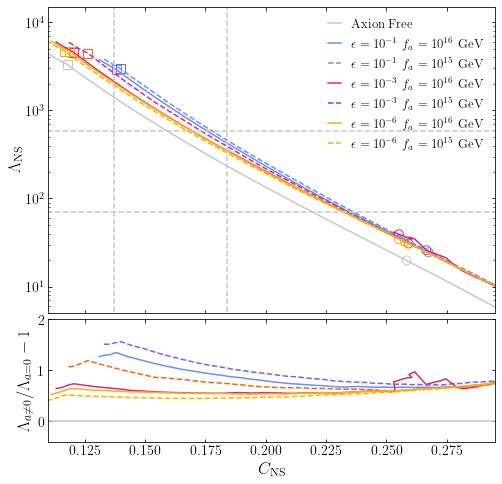

In [1304]:
labelfontsize = 17
legendfontsize = 13
tickfontsize = 14
mks = 2

start1, end1 = 18, -13
start2, end2 = 18, -13
start3, end3 = 18, -13
start4, end4 = 18, -13
start5, end5 = 18, -13
start6, end6 = 18, -13
start_TOV, end_TOV = 18, -13
sn = 7

boxindex = 3
circindex = -27
circTOV = -27
boxTOV = 3

# get differentials
# LCnoaxion_interpolating = interpol.interp1d(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 7])
LCnoaxion_interpolating = interpol.interp1d(meta_data_eps1e1_fa1e16[:, 6], meta_data_eps1e1_fa1e16[:, 7])
diffs_eps1e1_fa1e16 = 1 - smooth(meta_data_eps1e1_fa1e16[start1:end1, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e1_fa1e16[start1:end1, 10],sn))
diffs_eps1e1_fa1e15 = 1 - smooth(meta_data_eps1e1_fa1e15[start2:end2, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e1_fa1e15[start2:end2, 10],sn))

diffs_eps1e3_fa1e16 = 1 - smooth(meta_data_eps1e3_fa1e16[start3:end3, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e3_fa1e16[start3:end3, 10],sn))
diffs_eps1e3_fa1e15 = 1 - smooth(meta_data_eps1e3_fa1e15[start4:end4, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e3_fa1e15[start4:end4, 10],sn))

diffs_eps1e6_fa1e16 = 1 - smooth(meta_data_eps1e6_fa1e16[start5:end5, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e6_fa1e16[start5:end5, 10],sn))
diffs_eps1e6_fa1e15 = 1 - smooth(meta_data_eps1e6_fa1e15[start6:end6, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e6_fa1e15[start6:end6, 10],sn))
#diffs_eps1e6_fa1e14 = 1 - smooth(meta_data_eps1e6_fa1e14[start6:end6, 11],sn) / LCnoaxion_interpolating(smooth(meta_data_eps1e6_fa1e14[start6:end6, 10],sn))


# make the plots all fancy nice
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (8, 8), gridspec_kw={'height_ratios': [5, 2], 'hspace':0.03, 'wspace':0.15})

ax[0].plot(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], sn), smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 7], sn), '-', markersize=mks, color=colors[5], label=r'Axion Free')
ax[0].plot(smooth(meta_data_eps1e1_fa1e16[start1:end1, 10], sn), smooth(meta_data_eps1e1_fa1e16[start1:end1, 11], sn), '-', markersize=mks, color=colors[0], label=r'$\epsilon = 10^{-1} \ f_a = 10^{16}~\mathrm{GeV}$')
ax[0].plot(smooth(meta_data_eps1e1_fa1e15[start2:end2, 10], sn), smooth(meta_data_eps1e1_fa1e15[start2:end2, 11], sn), '--', markersize=mks, color=colors[0], label=r'$\epsilon = 10^{-1} \ f_a = 10^{15}~\mathrm{GeV}$')

ax[0].plot(smooth(meta_data_eps1e3_fa1e16[start3:end3, 10], sn), smooth(meta_data_eps1e3_fa1e16[start3:end3, 11], sn), '-', markersize=mks, color=colors[2], label=r'$\epsilon = 10^{-3} \ f_a = 10^{16}~\mathrm{GeV}$')
ax[0].plot(smooth(meta_data_eps1e3_fa1e15[start4:end4, 10], sn), smooth(meta_data_eps1e3_fa1e15[start4:end4, 11], sn), '--', markersize=mks, color=colors[2], label=r'$\epsilon = 10^{-3} \ f_a = 10^{15}~\mathrm{GeV}$')

ax[0].plot(smooth(meta_data_eps1e6_fa1e16[start5:end5, 10], sn), smooth(meta_data_eps1e6_fa1e16[start5:end5, 11], sn), '-', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{16}~\mathrm{GeV}$')
ax[0].plot(smooth(meta_data_eps1e6_fa1e15[start6:end6, 10], sn), smooth(meta_data_eps1e6_fa1e15[start6:end6, 11], sn), '--', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{15}~\mathrm{GeV}$')
#ax[0].plot(smooth(meta_data_eps1e6_fa1e14[start6:end6, 10], sn), smooth(meta_data_eps1e6_fa1e14[start6:end6, 11], sn), '-.', markersize=mks, color=colors[4], label=r'$\epsilon = 10^{-6} \ f_a = 10^{14}~\mathrm{GeV}$')


ax[0].scatter(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], sn)[boxTOV], smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 7], sn)[boxTOV], s=80, facecolors='none', edgecolor=colors[5], marker='s')
ax[0].scatter(smooth(meta_data_eps1e1_fa1e16[start1:end1, 10], sn)[boxindex], smooth(meta_data_eps1e1_fa1e16[start1:end1, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[0], marker='s')
ax[0].scatter(smooth(meta_data_eps1e1_fa1e15[start2:end2, 10], sn)[boxindex], smooth(meta_data_eps1e1_fa1e15[start2:end2, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[1], marker='s')
ax[0].scatter(smooth(meta_data_eps1e3_fa1e16[start3:end3, 10], sn)[boxindex], smooth(meta_data_eps1e3_fa1e16[start3:end3, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[2], marker='s')
ax[0].scatter(smooth(meta_data_eps1e3_fa1e15[start4:end4, 10], sn)[boxindex], smooth(meta_data_eps1e3_fa1e15[start4:end4, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[3], marker='s')
ax[0].scatter(smooth(meta_data_eps1e6_fa1e16[start5:end5, 10], sn)[boxindex], smooth(meta_data_eps1e6_fa1e16[start5:end5, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')
ax[0].scatter(smooth(meta_data_eps1e6_fa1e15[start6:end6, 10], sn)[boxindex], smooth(meta_data_eps1e6_fa1e15[start6:end6, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')
#ax[0].scatter(smooth(meta_data_eps1e6_fa1e14[start6:end6, 10], sn)[boxindex], smooth(meta_data_eps1e6_fa1e14[start6:end6, 11], sn)[boxindex], s=80, facecolors='none', edgecolor=colors[4], marker='s')

ax[0].scatter(smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 6], sn)[circTOV], smooth(meta_data_eps1e1_fa1e16[start_TOV:end_TOV, 7], sn)[circTOV], s=80, facecolors='none', edgecolor=colors[5])
ax[0].scatter(smooth(meta_data_eps1e1_fa1e16[start1:end1, 10], sn)[circindex], smooth(meta_data_eps1e1_fa1e16[start1:end1, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[0])
ax[0].scatter(smooth(meta_data_eps1e1_fa1e15[start2:end2, 10], sn)[circindex], smooth(meta_data_eps1e1_fa1e15[start2:end2, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[1])
ax[0].scatter(smooth(meta_data_eps1e3_fa1e16[start3:end3, 10], sn)[circindex], smooth(meta_data_eps1e3_fa1e16[start3:end3, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[2])
ax[0].scatter(smooth(meta_data_eps1e3_fa1e15[start4:end4, 10], sn)[circindex], smooth(meta_data_eps1e3_fa1e15[start4:end4, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[3])
ax[0].scatter(smooth(meta_data_eps1e6_fa1e16[start5:end5, 10], sn)[circindex], smooth(meta_data_eps1e6_fa1e16[start5:end5, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])
ax[0].scatter(smooth(meta_data_eps1e6_fa1e15[start6:end6, 10], sn)[circindex], smooth(meta_data_eps1e6_fa1e15[start6:end6, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])
#ax[0].scatter(smooth(meta_data_eps1e6_fa1e14[start6:end6, 10], sn)[circindex], smooth(meta_data_eps1e6_fa1e14[start6:end6, 11], sn)[circindex], s=80, facecolors='none', edgecolor=colors[4])

upperlimit = 190+390#6e2
lowerlimit = 190-120#7e1
rightlimit = 0.159+0.025
leftlimit  = 0.159-0.022
ax[0].plot([1e-3, 1e2], [upperlimit, upperlimit], '--', color=colors[5])
ax[0].plot([1e-3, 1e2], [lowerlimit, lowerlimit], '--', color=colors[5])
ax[0].plot([rightlimit, rightlimit], [1e-1, 1e8], '--', color=colors[5])
ax[0].plot([leftlimit, leftlimit], [1e-1, 1e8], '--', color=colors[5])


ax[1].plot(smooth(meta_data_eps1e1_fa1e16[start1:end1, 10],sn), -diffs_eps1e1_fa1e16, '-', color=colors[0])
ax[1].plot(smooth(meta_data_eps1e1_fa1e15[start2:end2, 10],sn), -diffs_eps1e1_fa1e15, '--', color=colors[1])
ax[1].plot(smooth(meta_data_eps1e3_fa1e16[start3:end3, 10],sn), -diffs_eps1e3_fa1e16, '-', color=colors[2])
ax[1].plot(smooth(meta_data_eps1e3_fa1e15[start4:end4, 10],sn), -diffs_eps1e3_fa1e15, '--', color=colors[3])
ax[1].plot(smooth(meta_data_eps1e6_fa1e16[start5:end5, 10],sn), -diffs_eps1e6_fa1e16, '-', color=colors[4])
ax[1].plot(smooth(meta_data_eps1e6_fa1e15[start6:end6, 10],sn), -diffs_eps1e6_fa1e15, '--', color=colors[4])
#ax[1].plot(smooth(meta_data_eps1e6_fa1e14[start6:end6, 10],sn), -diffs_eps1e6_fa1e14, '-.', color=colors[4])
ax[1].plot([0.0, 0.35], [0,0], '-', color=colors[5])


ax[1].set_xlabel(r'$C_{\rm NS}$', fontname="serif", fontsize=labelfontsize)
ax[0].set_ylabel(r'$\Lambda_{\rm NS}$', fontname="serif", fontsize=labelfontsize)
ax[1].set_ylabel(r'$\Lambda_{a \neq 0}/\Lambda_{a = 0} - 1$', fontname="serif", fontsize=labelfontsize)
ax[0].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=False)
ax[1].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax[0].legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)
ax[0].set_xlim(0.11, 0.295)
ax[1].set_xlim(0.11, 0.295)
ax[0].set_ylim(5.0, 1.5e4)
ax[1].set_ylim(-0.4, 2.0)
ax[0].set_yscale("log")


plt.savefig(plotdirectory + "LC-with-limits.pdf", format="pdf", bbox_inches="tight")

plt.show()

# EOS Curves

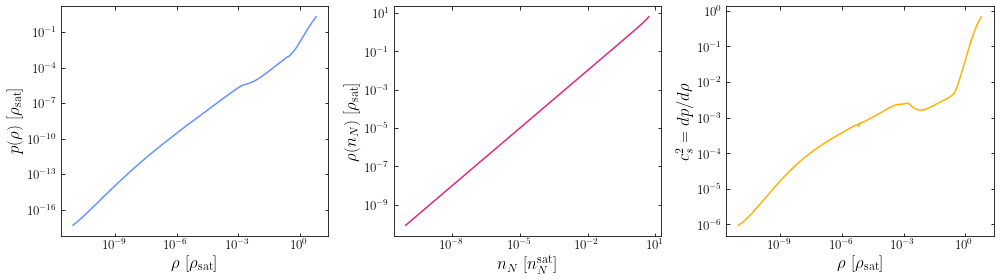

In [940]:
#fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (15, 4))
from matplotlib.ticker import ScalarFormatter

y_formatter = ScalarFormatter()
y_formatter.set_scientific(False)

labelfontsize = 17
legendfontsize = 13
tickfontsize = 13
mks = 2

rhosat = mN*nsatinGeV3

densities = np.logspace(-14, -2.15, 1000)
EOSvals = EOS(densities)
c2vals = dEOSdrho(densities)
nNvals = np.logspace(-13, -2.2, 1000)
rhoofnNvals = NRHO(nNvals)

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (14, 4))

ax[0].loglog(densities[1:]/rhosat, EOSvals[1:]/rhosat, color=colors[0])
#ax[0].set_xlim(0.0,)
#ax[0].set_xlabel(r'$r$ (km)', fontname="serif", fontsize=14)
ax[0].set_xlabel(r'$\rho~[\rho_{\rm sat}]$', fontname="serif", fontsize=labelfontsize)
ax[0].set_ylabel(r'$p(\rho)~[\rho_{\rm sat}]$', fontname="serif", fontsize=labelfontsize)
ax[0].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True)
#ax[0].legend()

ax[2].loglog(densities[1:]/rhosat, c2vals[1:], color=colors[4])
#ax[0].set_xlim(0.0,)
#ax[0].set_xlabel(r'$r$ (km)', fontname="serif", fontsize=14)
ax[2].set_xlabel(r'$\rho~[\rho_{\rm sat}]$', fontname="serif", fontsize=labelfontsize)
ax[2].set_ylabel(r'$c_s^2 = d p / d \rho$', fontname="serif", fontsize=labelfontsize)
ax[2].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True)
ax[2].minorticks_off()
#ax[0].legend()

ax[1].loglog(nNvals[1:]/nsatinGeV3, (rhoofnNvals[1:]/rhosat), color=colors[2])
#ax[1].set_xlim(1e-14, 5e-2)
#ax[0].set_xlabel(r'$r$ (km)', fontname="serif", fontsize=14)
ax[1].set_xlabel(r'$n_N~[n_N^{\rm sat}]$', fontname="serif", fontsize=labelfontsize)
ax[1].set_ylabel(r'$\rho(n_N)~[\rho_{\rm sat}]$', fontname="serif", fontsize=labelfontsize)
ax[1].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True)
#ax[1].yaxis.set_minor_formatter(y_formatter)

plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.6, wspace=0.6)
plt.tight_layout()

plt.savefig(plotdirectory + "EOS-c2-mN-units-GeV.pdf", format="pdf", bbox_inches="tight")
#plt.savefig(plotdirectory + "fractional-internal-energy.pdf", format="pdf", bbox_inches="tight")

plt.show()

# Domain Wall analysis

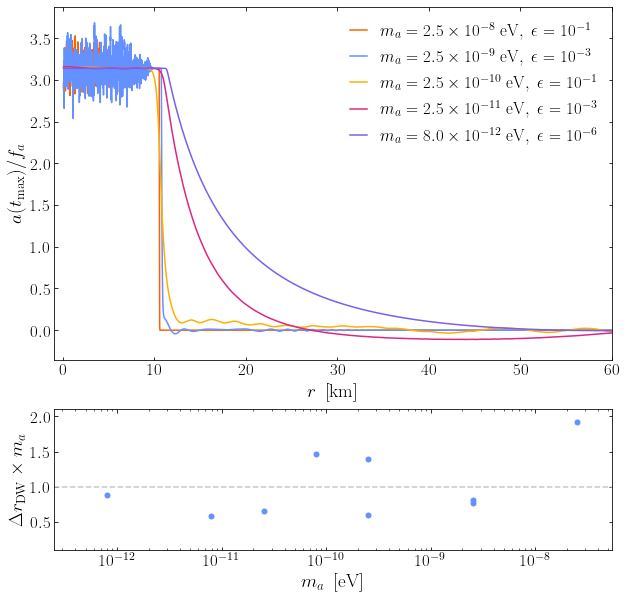

In [82]:
domainwalls = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/domain-wall-analysis/domain-wall-analysis.npy")

rvals = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/domain-wall-analysis/radii.npy")
Avals = np.zeros((9, 10000))
for i in range(9):
    Mtemp = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/domain-wall-analysis/M-" + str(int(396 + i)) + ".npy")
    Atemp = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/domain-wall-analysis/A-" + str(int(396 + i)) + ".npy")
    final_index = int(len(Mtemp) / 20 - 1)
    Avals[i, :] = smooth(Atemp[final_index, :], 2)

labelfontsize = 19
legendfontsize = 17
tickfontsize = 17
mks = 5

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (10, 10), gridspec_kw={'height_ratios': [5, 2], 'hspace':0.2, 'wspace':0.25})

ax[0].plot(rvals[6:]*GeV_2_km, Avals[2, 6:], label=r'$m_a = 2.5 \times 10^{-8}~\mathrm{eV}, \ \epsilon = 10^{-1}$', color=colors[3])
ax[0].plot(rvals[8:]*GeV_2_km, Avals[5, 8:], label=r'$m_a = 2.5 \times 10^{-9}~\mathrm{eV}, \ \epsilon = 10^{-3}$', color=colors[0])
ax[0].plot(rvals[6:]*GeV_2_km, Avals[0, 6:], label=r'$m_a = 2.5 \times 10^{-10}~\mathrm{eV}, \ \epsilon = 10^{-1}$', color=colors[4])
ax[0].plot(rvals[6:]*GeV_2_km, Avals[3, 6:], label=r'$m_a = 2.5 \times 10^{-11}~\mathrm{eV}, \ \epsilon = 10^{-3}$', color=colors[2])
ax[0].plot(rvals[6:]*GeV_2_km, Avals[7, 6:], label=r'$m_a = 8.0 \times 10^{-12}~\mathrm{eV}, \ \epsilon = 10^{-6}$', color=colors[1])

ax[0].set_ylabel(r'$a(t_{\rm max}) / f_a$', fontname="serif", fontsize=labelfontsize)
ax[0].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax[0].legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)
ax[0].set_xlim(-1.0, 60.0)

ax[1].plot(domainwalls[:, 3]*1e9, domainwalls[:, 5]*domainwalls[:,3], 'o', markersize=mks, color=colors[0])
ax[1].plot([2*np.pi*6e1*1e9/(GeV_2_Hz), 2*np.pi*1.3e7*1e9/(GeV_2_Hz)], [1.0, 1.0], '--', markersize=mks, color=colors[5])
ax[1].set_xlabel(r'$m_a~\left[\mathrm{eV}\right]$', fontname="serif", fontsize=labelfontsize)
ax[1].set_ylabel(r'$\Delta r_{\rm DW} \times m_a$ ', fontname="serif", fontsize=labelfontsize)
ax[1].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax[1].set_ylim(0.1, 2.1)
ax[1].set_xlim(2*np.pi*6e1*1e9/(GeV_2_Hz), 2*np.pi*1.3e7*1e9/(GeV_2_Hz))
ax[1].set_xscale('log')
#ax[1].set_yscale('log')

plt.savefig(plotdirectory + "DW-eps.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [1257]:
1e-8 / (rvals[1] - rvals[0])**2

3.8930161022106604e-42

# Frequency Analysis

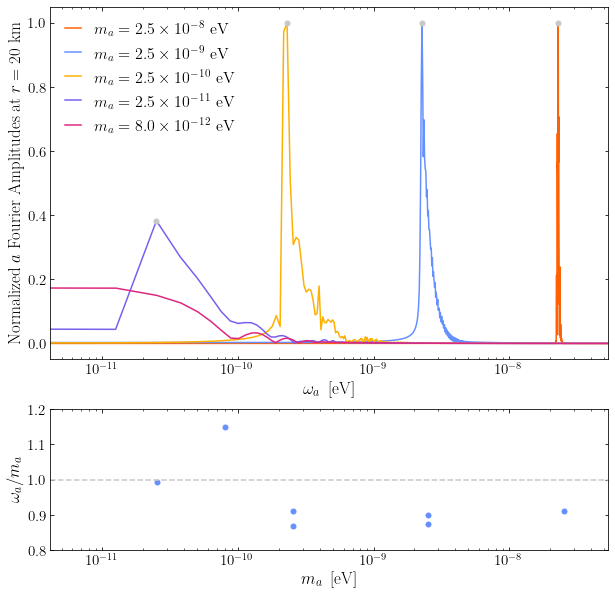

In [40]:
peak_data = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/peak_frequency_data.npy")

GeV_2_Hz = 1.51927e+24

AmplitudeSets = []
FrequencySets = []

AmplitudeSetsPeaks = []
FrequencySetsPeaks = []

plot_peaks = []
plot_freqs = []

for i in range(9):
    Atemp = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/domain-wall-analysis/amplitude_data_" + str(int(396 + i)) + ".npy")
    ftemp = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/domain-wall-analysis/frequency_data_" + str(int(396 + i)) + ".npy")
    AmplitudeSets.append(Atemp)
    FrequencySets.append(ftemp)
    
    Atemppeak = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/domain-wall-analysis/amplitude_peaks_" + str(int(396 + i)) + ".npy")
    ftemppeak = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/domain-wall-analysis/frequency_peaks_" + str(int(396 + i)) + ".npy")
    AmplitudeSetsPeaks.append(Atemppeak)
    FrequencySetsPeaks.append(ftemppeak)
    
    plot_peaks.append(np.max(Atemppeak) / np.max(Atemp))
    plot_freqs.append(ftemppeak[np.argmax(Atemppeak)])
    
epsilons = [1e-1, 1e-3, 1e-6]
fas = [1e16, 1e15, 1e14]
masses = []
for i in range(3):
    for j in range(3):
        masses.append(beta*np.sqrt(epsilons[i])*mpi*fpi/(2*fas[j]))
    
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (10, 10), gridspec_kw={'height_ratios': [5, 2], 'hspace':0.2, 'wspace':0.25})

ax[0].plot(2*np.pi*FrequencySets[2]*1e9, AmplitudeSets[2]/np.max(AmplitudeSets[2]), label=r'$m_a = 2.5 \times 10^{-8}~\mathrm{eV}$', color=colors[3])
ax[0].plot([2*np.pi*plot_freqs[2]*1e9], [plot_peaks[2]], 'o', markersize=mks, color=colors[5])
ax[0].plot(2*np.pi*FrequencySets[5]*1e9, AmplitudeSets[5]/np.max(AmplitudeSets[5]), label=r'$m_a = 2.5 \times 10^{-9}~\mathrm{eV}$', color=colors[0])
ax[0].plot([2*np.pi*plot_freqs[5]*1e9], [plot_peaks[5]], 'o', markersize=mks, color=colors[5])
ax[0].plot(2*np.pi*FrequencySets[0]*1e9, AmplitudeSets[0]/np.max(AmplitudeSets[0]), label=r'$m_a = 2.5 \times 10^{-10}~\mathrm{eV}$', color=colors[4])
ax[0].plot([2*np.pi*plot_freqs[0]*1e9], [plot_peaks[0]], 'o', markersize=mks, color=colors[5])
ax[0].plot(2*np.pi*FrequencySets[3]*1e9, AmplitudeSets[3]/np.max(AmplitudeSets[3]), label=r'$m_a = 2.5 \times 10^{-11}~\mathrm{eV}$', color=colors[1])
ax[0].plot([2*np.pi*plot_freqs[3]*1e9], [plot_peaks[3]], 'o', markersize=mks, color=colors[5])
ax[0].plot(2*np.pi*FrequencySets[7]*1e9, AmplitudeSets[7]/np.max(AmplitudeSets[7]), label=r'$m_a = 8.0 \times 10^{-12}~\mathrm{eV}$', color=colors[2])
#ax[0].plot([2*np.pi*plot_freqs[7]], [plot_peaks[7]], 'o', markersize=mks, color=colors[5])


#ax[0].plot(FrequencySets[2]*GeV_2_Hz, AmplitudeSets[2]/np.max(AmplitudeSets[2]), label=r'$m_a = 1.8 \times 10^{-17}~\mathrm{GeV}$', color=colors[3])
#ax[0].plot(FrequencySets[5]*GeV_2_Hz, AmplitudeSets[5]/np.max(AmplitudeSets[5]), label=r'$m_a = 1.8 \times 10^{-18}~\mathrm{GeV}$', color=colors[0])
#ax[0].plot(FrequencySets[4]*GeV_2_Hz, AmplitudeSets[4]/np.max(AmplitudeSets[4]), label=r'$m_a = 1.8 \times 10^{-19}~\mathrm{GeV}$', color=colors[4])
# ax[0].plot(FrequencySets[7]*GeV_2_Hz, AmplitudeSets[7]/np.max(AmplitudeSets[7]), label=r'$m_a = 5.6 \times 10^{-21}~\mathrm{GeV}$', color=colors[1])
# ax[0].plot(FrequencySets[6]*GeV_2_Hz, AmplitudeSets[6]/np.max(AmplitudeSets[6]), label=r'$m_a = 5.6 \times 10^{-22}~\mathrm{GeV}$', color=colors[2])

ax[0].set_ylabel(r'Normalized $a$ Fourier Amplitudes at $r = 20~\mathrm{km}$', fontname="serif", fontsize=labelfontsize)
ax[0].set_xlabel(r'$\omega_a~\left[\mathrm{eV}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax[0].legend(frameon=False, fontsize=legendfontsize, loc=2, handlelength=1)
ax[0].set_xlim(2*np.pi*1e3*1e9/(GeV_2_Hz), 2*np.pi*1.3e7*1e9/(GeV_2_Hz))
ax[0].set_xscale('log')
# ax[0].set_yscale('log')

ax[1].plot(np.array(masses)*1e9, 2*np.pi*np.array(plot_freqs) / np.array(masses), 'o', markersize=mks, color=colors[0])
ax[1].plot([2*np.pi*1e3*1e9/(GeV_2_Hz), 2*np.pi*1.3e7*1e9/(GeV_2_Hz)], [1.0, 1.0], '--', markersize=mks, color=colors[5])
ax[1].set_xlabel(r'$m_a~\left[\mathrm{eV}\right]$', fontname="serif", fontsize=labelfontsize)
ax[1].set_ylabel(r'$\omega_a / m_a$', fontname="serif", fontsize=labelfontsize)
ax[1].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax[1].set_xscale('log')
ax[1].set_ylim(0.8, 1.2)
ax[1].set_xlim(2*np.pi*1e3*1e9/(GeV_2_Hz), 2*np.pi*1.3e7*1e9/(GeV_2_Hz))

plt.savefig(plotdirectory + "frequencies.pdf", format="pdf", bbox_inches="tight")

plt.show()


# Initial vs. Final State

[204 206 218 222 232 236 247 251 261 266 275 282 289 296 304 309 318 324
 333 338 347 353 361 367 376 382 390 395 405 410 419 424 434 439]
136.097553279678


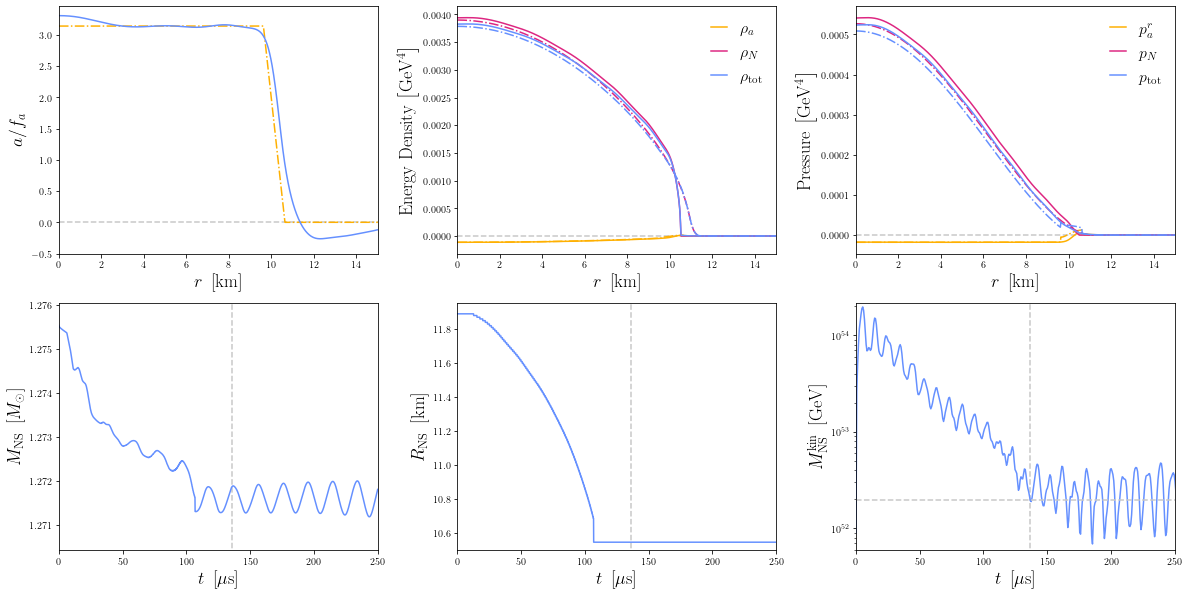

In [1277]:
datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/ic-vs-fs/"

import numpy as np

def zero_crossings_indices(arr, min_index=0):
    arr = np.asarray(arr)
    signs = np.sign(arr)
    sign_changes = np.where(np.diff(signs) != 0)[0]
    return sign_changes[sign_changes > min_index]

Avals = np.load(datadirectory + "A-solution.npy")
rvals = np.load(datadirectory + "radii.npy")
tvals = np.load(datadirectory + "times.npy")
Pvals = np.load(datadirectory + "P-solution.npy")
Fvals = np.load(datadirectory + "F-solution.npy")
Gvals = np.load(datadirectory + "G-solution.npy")
Uvals = np.load(datadirectory + "U-solution.npy")
nNvals = np.load(datadirectory + "nN-solution.npy")

NSmasses = np.load(datadirectory + "NSmasses.npy")
NSradii = np.load(datadirectory + "NSradii.npy")

Ntot_initial = np.sum(4*np.pi*rvals**2 * Gvals[0,:]*nNvals[0,:] / np.sqrt(1 - Uvals[0,:]**2))
Ntot_final   = np.sum(4*np.pi*rvals**2 * Gvals[final_index,:]*nNvals[final_index,:] / np.sqrt(1 - Uvals[final_index,:]**2))

epsilon = 1e-1
fa = 1e16

# get kinetic energy fractions
KE_vals = []
for i in range(int(len(NSmasses)/20 - 1)):
    #Fvals[i,:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]*Gvals[i,:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]
    KE_vals.append(np.sum(4*np.pi*(rvals[1] - rvals[0])*Fvals[i,:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]*Gvals[i,:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]*rvals[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]**2*kinetic_energy_density(rvals, Gvals[i,:], nNvals[i,:], Uvals[i,:], Avals[i,:], Pvals[i,:], epsilon, fa)[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]) )#/ NSmasses[i*20])

final_index = np.argmin(np.abs(KE_vals[100:] - 0.01*np.max(KE_vals))) + 190 #int(len(NSmasses)/20 - 1) -10 
end_index = 30

AxionDensityIC = axion_density(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)
BaryonDensityIC = baryon_density(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)
TotalDensityIC = total_density(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)

AxionDensityFS = axion_density(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)
BaryonDensityFS = baryon_density(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)
TotalDensityFS = total_density(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)

AxionPressureIC = axion_pressure(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)
BaryonPressureIC = baryon_pressure(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)
TotalPressureIC = total_pressure(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)

AxionPressureFS = axion_pressure(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)
BaryonPressureFS = baryon_pressure(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)
TotalPressureFS = total_pressure(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)


# find the roots of the function
# KEfnc = interpol.interp1d(tvals[0:final_index*20:20], KE_vals)
# zerofnc = lambda t: (KEfnc(t) - 0.01*np.max(KE_vals))
# my_roots = opt.fsolve(zerofnc, [1e18, 1e20, 2e20])

cutoff_index = np.argmin(np.abs(KE_vals[100:] - 0.01*np.max(KE_vals))) + 100
tfin = tvals[cutoff_index*20]*GeV_2_km*10**3 *10**6 / clight
#print(tfin)

print(zero_crossings_indices(KE_vals - 0.01*np.max(KE_vals), min_index=50))

tcutindex = np.min(zero_crossings_indices(KE_vals - 0.01*np.max(KE_vals)*np.ones(np.shape(KE_vals)), min_index=50))
#print(tcut)
tcut = tvals[20*tcutindex]*GeV_2_km*1e3*1e6/clight
print(tcut)

labelfontsize = 18
legendfontsize = 16
tickfontsize = 30
mks = 5

maxrad = 15

fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = (20, 10), gridspec_kw={'hspace':0.2, 'wspace':0.25})

ax[0,0].plot([0.0, 100.0],[0.0, 0.0], '--', color=colors[5])
ax[0,0].plot(rvals*GeV_2_km, Avals[0, :], '-.', color=colors[4])
ax[0,0].plot(rvals*GeV_2_km, Avals[final_index, :], '-', color=colors[0])
ax[0,0].set_xlim(0, maxrad)
ax[0,0].set_ylim(-0.5, np.pi*1.1)
ax[0,0].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,0].set_ylabel(r'$a / f_a$ ', fontname="serif", fontsize=labelfontsize)

ax[0,1].plot([0.0, 100.0],[0.0, 0.0], '--', color=colors[5])
ax[0,1].plot(rvals*GeV_2_km, AxionDensityIC, '-.', color=colors[4])
ax[0,1].plot(rvals*GeV_2_km, AxionDensityFS, '-', color=colors[4], label=r'$\rho_a$')
ax[0,1].plot(rvals*GeV_2_km, BaryonDensityIC, '-.', color=colors[2])
ax[0,1].plot(rvals*GeV_2_km, BaryonDensityFS, '-', color=colors[2], label=r'$\rho_N$')
ax[0,1].plot(rvals*GeV_2_km, TotalDensityIC, '-.', color=colors[0])
ax[0,1].plot(rvals*GeV_2_km, TotalDensityFS, '-', color=colors[0], label=r'$\rho_{\rm tot}$')
ax[0,1].set_xlim(0, maxrad)
ax[0,1].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,1].set_ylabel(r'Energy Density $\left[\mathrm{GeV}^4\right]$', fontname="serif", fontsize=labelfontsize)
ax[0,1].legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)

ax[0,2].plot([0.0, 100.0],[0.0, 0.0], '--', color=colors[5])
ax[0,2].plot(rvals*GeV_2_km, AxionPressureIC, '-.', color=colors[4])
ax[0,2].plot(rvals*GeV_2_km, AxionPressureFS, '-', color=colors[4], label=r'$p^r_a$')
ax[0,2].plot(rvals*GeV_2_km, BaryonPressureIC, '-.', color=colors[2])
ax[0,2].plot(rvals*GeV_2_km, BaryonPressureFS, '-', color=colors[2], label=r'$p_N$')
ax[0,2].plot(rvals*GeV_2_km, TotalPressureIC, '-.', color=colors[0])
ax[0,2].plot(rvals*GeV_2_km, TotalPressureFS, '-', color=colors[0], label=r'$p_{\rm tot}$')
ax[0,2].set_xlim(0, maxrad)
ax[0,2].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,2].set_ylabel(r'Pressure $\left[\mathrm{GeV}^4\right]$', fontname="serif", fontsize=labelfontsize)
ax[0,2].legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)

ax[1,0].plot([tcut, tcut], [1e-10, 10], '--', color=colors[5])
ax[1,0].plot(tvals[:len(NSmasses)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses[:-end_index]*GeV_2_kg*kg_2_Msun, '-', color=colors[0])
ax[1,0].set_xlim(0, 250)
ax[1,0].set_ylim(NSmasses[0]*0.996*GeV_2_kg*kg_2_Msun, NSmasses[0]*1.0004*GeV_2_kg*kg_2_Msun)
ax[1,0].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,0].set_ylabel(r'$M_{\rm NS}~\left[M_{\odot}\right]$ ', fontname="serif", fontsize=labelfontsize)

ax[1,1].plot([tcut, tcut], [1e-10, 20], '--', color=colors[5])
ax[1,1].plot(tvals[:len(NSmasses)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii[:-end_index]*GeV_2_km, '-', color=colors[0])
ax[1,1].set_xlim(0, 250)
ax[1,1].set_ylim(10.5, 11.95)
ax[1,1].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,1].set_ylabel(r'$R_{\rm NS}~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)

ax[1,2].plot([tcut, tcut], [1e-10, 1e60], '--', color=colors[5])
ax[1,2].plot(tvals[0:(len(NSmasses)-end_index):20]*GeV_2_km*10**3 *10**6 / clight, KE_vals, '-', color=colors[0])
ax[1,2].plot([0.0, 310], [0.01*np.max(KE_vals), 0.01*np.max(KE_vals)], '--', color=colors[5])
ax[1,2].set_yscale('log')
ax[1,2].set_xlim(0.0, 250)
ax[1,2].set_ylim(np.min(KE_vals)*0.9, np.max(KE_vals)*1.1)
ax[1,2].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,2].set_ylabel(r'$M_{\rm NS}^{\rm kin}~\left[\mathrm{GeV}\right]$', fontname="serif", fontsize=labelfontsize)

plt.savefig(plotdirectory + "ic-vs-fs.pdf", format="pdf", bbox_inches="tight")

plt.show()


[295]
196.80773636031873


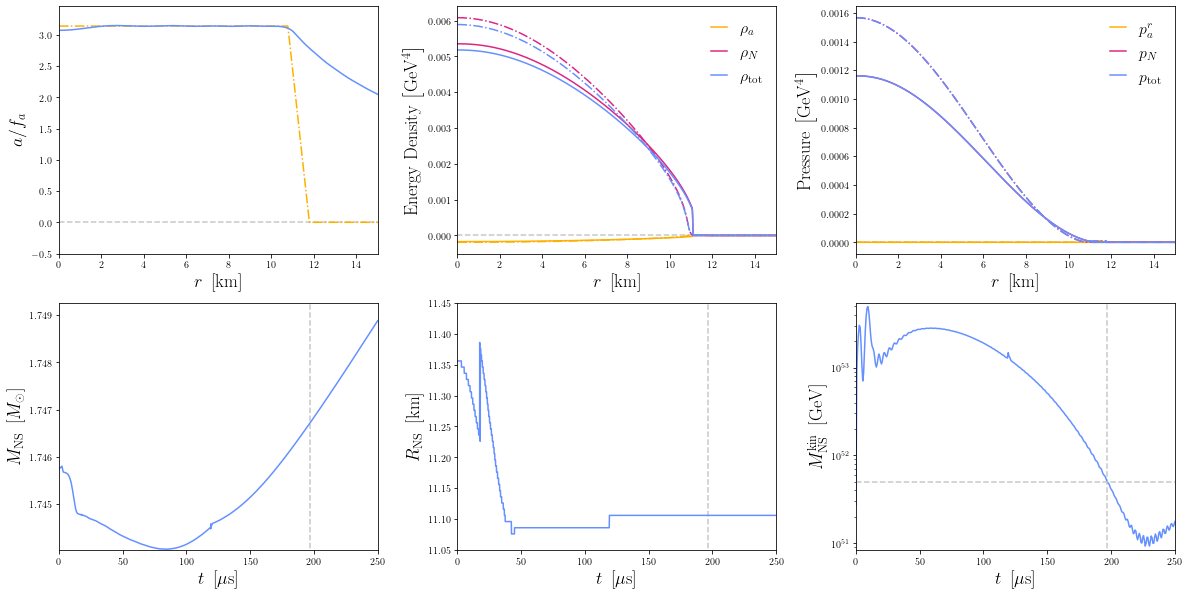

In [88]:
datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/ic-vs-fs/eps06/"

import numpy as np

def zero_crossings_indices(arr, min_index=0):
    arr = np.asarray(arr)
    signs = np.sign(arr)
    sign_changes = np.where(np.diff(signs) != 0)[0]
    return sign_changes[sign_changes > min_index]

Avals = np.load(datadirectory + "A-solution.npy")
rvals = np.load(datadirectory + "radii.npy")
tvals = np.load(datadirectory + "times.npy")
Pvals = np.load(datadirectory + "P-solution.npy")
Fvals = np.load(datadirectory + "F-solution.npy")
Gvals = np.load(datadirectory + "G-solution.npy")
Uvals = np.load(datadirectory + "U-solution.npy")
nNvals = np.load(datadirectory + "nN-solution.npy")

NSmasses = np.load(datadirectory + "NSmasses.npy")
NSradii = np.load(datadirectory + "NSradii.npy")

Ntot_initial = np.sum(4*np.pi*rvals**2 * Gvals[0,:]*nNvals[0,:] / np.sqrt(1 - Uvals[0,:]**2))
Ntot_final   = np.sum(4*np.pi*rvals**2 * Gvals[final_index,:]*nNvals[final_index,:] / np.sqrt(1 - Uvals[final_index,:]**2))

epsilon = 1e-6
fa = 1e16

# get kinetic energy fractions
KE_vals = []
for i in range(int(len(NSmasses)/20 - 1)):
    #Fvals[i,:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]*Gvals[i,:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]
    KE_vals.append(np.sum(4*np.pi*(rvals[1] - rvals[0])*Fvals[i,:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]*Gvals[i,:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]*rvals[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]**2*kinetic_energy_density(rvals, Gvals[i,:], nNvals[i,:], Uvals[i,:], Avals[i,:], Pvals[i,:], epsilon, fa)[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii[i*20]))]) )#/ NSmasses[i*20])

final_index = np.argmin(np.abs(KE_vals[100:] - 0.01*np.max(KE_vals))) + 190 #int(len(NSmasses)/20 - 1) -10 
end_index = 30

AxionDensityIC = axion_density(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)
BaryonDensityIC = baryon_density(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)
TotalDensityIC = total_density(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)

AxionDensityFS = axion_density(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)
BaryonDensityFS = baryon_density(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)
TotalDensityFS = total_density(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)

AxionPressureIC = axion_pressure(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)
BaryonPressureIC = baryon_pressure(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)
TotalPressureIC = total_pressure(rvals, Gvals[0,:], nNvals[0,:], Uvals[0,:], Avals[0,:], Pvals[0,:], epsilon, fa)

AxionPressureFS = axion_pressure(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)
BaryonPressureFS = baryon_pressure(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)
TotalPressureFS = total_pressure(rvals, Gvals[final_index,:], nNvals[final_index,:], Uvals[final_index,:], Avals[final_index,:], Pvals[final_index,:], epsilon, fa)


# find the roots of the function
# KEfnc = interpol.interp1d(tvals[0:final_index*20:20], KE_vals)
# zerofnc = lambda t: (KEfnc(t) - 0.01*np.max(KE_vals))
# my_roots = opt.fsolve(zerofnc, [1e18, 1e20, 2e20])

cutoff_index = np.argmin(np.abs(KE_vals[100:] - 0.01*np.max(KE_vals))) + 100
tfin = tvals[cutoff_index*20]*GeV_2_km*10**3 *10**6 / clight
#print(tfin)

print(zero_crossings_indices(KE_vals - 0.01*np.max(KE_vals), min_index=50))

tcutindex = np.min(zero_crossings_indices(KE_vals - 0.01*np.max(KE_vals)*np.ones(np.shape(KE_vals)), min_index=50))
#print(tcut)
tcut = tvals[20*tcutindex]*GeV_2_km*1e3*1e6/clight
print(tcut)

labelfontsize = 18
legendfontsize = 16
tickfontsize = 30
mks = 5

maxrad = 15

fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = (20, 10), gridspec_kw={'hspace':0.2, 'wspace':0.25})

ax[0,0].plot([0.0, 100.0],[0.0, 0.0], '--', color=colors[5])
ax[0,0].plot(rvals*GeV_2_km, Avals[0, :], '-.', color=colors[4])
ax[0,0].plot(rvals*GeV_2_km, Avals[final_index, :], '-', color=colors[0])
ax[0,0].set_xlim(0, maxrad)
ax[0,0].set_ylim(-0.5, np.pi*1.1)
ax[0,0].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,0].set_ylabel(r'$a / f_a$ ', fontname="serif", fontsize=labelfontsize)

ax[0,1].plot([0.0, 100.0],[0.0, 0.0], '--', color=colors[5])
ax[0,1].plot(rvals*GeV_2_km, AxionDensityIC, '-.', color=colors[4])
ax[0,1].plot(rvals*GeV_2_km, AxionDensityFS, '-', color=colors[4], label=r'$\rho_a$')
ax[0,1].plot(rvals*GeV_2_km, BaryonDensityIC, '-.', color=colors[2])
ax[0,1].plot(rvals*GeV_2_km, BaryonDensityFS, '-', color=colors[2], label=r'$\rho_N$')
ax[0,1].plot(rvals*GeV_2_km, TotalDensityIC, '-.', color=colors[0])
ax[0,1].plot(rvals*GeV_2_km, TotalDensityFS, '-', color=colors[0], label=r'$\rho_{\rm tot}$')
ax[0,1].set_xlim(0, maxrad)
ax[0,1].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,1].set_ylabel(r'Energy Density $\left[\mathrm{GeV}^4\right]$', fontname="serif", fontsize=labelfontsize)
ax[0,1].legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)

ax[0,2].plot([0.0, 100.0],[0.0, 0.0], '--', color=colors[5])
ax[0,2].plot(rvals*GeV_2_km, AxionPressureIC, '-.', color=colors[4])
ax[0,2].plot(rvals*GeV_2_km, AxionPressureFS, '-', color=colors[4], label=r'$p^r_a$')
ax[0,2].plot(rvals*GeV_2_km, BaryonPressureIC, '-.', color=colors[2])
ax[0,2].plot(rvals*GeV_2_km, BaryonPressureFS, '-', color=colors[2], label=r'$p_N$')
ax[0,2].plot(rvals*GeV_2_km, TotalPressureIC, '-.', color=colors[0])
ax[0,2].plot(rvals*GeV_2_km, TotalPressureFS, '-', color=colors[0], label=r'$p_{\rm tot}$')
ax[0,2].set_xlim(0, maxrad)
ax[0,2].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,2].set_ylabel(r'Pressure $\left[\mathrm{GeV}^4\right]$', fontname="serif", fontsize=labelfontsize)
ax[0,2].legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)

ax[1,0].plot([tcut, tcut], [1e-10, 10], '--', color=colors[5])
ax[1,0].plot(tvals[:len(NSmasses)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses[:-end_index]*GeV_2_kg*kg_2_Msun, '-', color=colors[0])
ax[1,0].set_xlim(0, 250)
ax[1,0].set_ylim(NSmasses[0]*0.999*GeV_2_kg*kg_2_Msun, NSmasses[0]*1.002*GeV_2_kg*kg_2_Msun)
ax[1,0].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,0].set_ylabel(r'$M_{\rm NS}~\left[M_{\odot}\right]$ ', fontname="serif", fontsize=labelfontsize)

ax[1,1].plot([tcut, tcut], [1e-10, 20], '--', color=colors[5])
ax[1,1].plot(tvals[:len(NSmasses)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii[:-end_index]*GeV_2_km, '-', color=colors[0])
ax[1,1].set_xlim(0, 250)
ax[1,1].set_ylim(11.05, 11.45)
ax[1,1].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,1].set_ylabel(r'$R_{\rm NS}~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)

ax[1,2].plot([tcut, tcut], [1e-10, 1e60], '--', color=colors[5])
ax[1,2].plot(tvals[0:(len(NSmasses)-end_index):20]*GeV_2_km*10**3 *10**6 / clight, KE_vals, '-', color=colors[0])
ax[1,2].plot([0.0, 310], [0.01*np.max(KE_vals), 0.01*np.max(KE_vals)], '--', color=colors[5])
ax[1,2].set_yscale('log')
ax[1,2].set_xlim(0.0, 250)
ax[1,2].set_ylim(np.min(KE_vals)*0.9, np.max(KE_vals)*1.1)
ax[1,2].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,2].set_ylabel(r'$M_{\rm NS}^{\rm kin}~\left[\mathrm{GeV}\right]$', fontname="serif", fontsize=labelfontsize)

plt.savefig(plotdirectory + "ic-vs-fs-eps06.pdf", format="pdf", bbox_inches="tight")

plt.show()


# Potential Contour Plot

5.218602710849154e-06


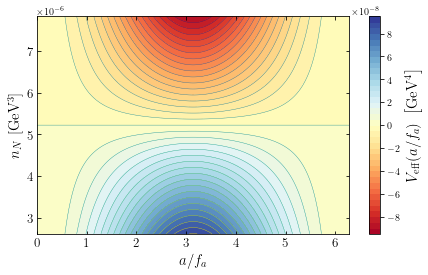

In [120]:
def faxion(theta):
    return np.sqrt(1 - (4*(mu*md)/(mu+md)**2) * np.sin(theta/2)**2);

def V_eff(theta, N0, eps):
    return -mpi**2 * fpi**2 * (eps - sigmaN*N0/(mpi**2*fpi**2)) * (faxion(theta) - 1)

nNcrit = 1e-3 * mpi**2 * fpi**2 / sigmaN
print(nNcrit)

thetavals = np.linspace(0, 2*np.pi, 400)
N0vals = np.linspace(0.5 * nNcrit, 1.5 * nNcrit, 400)

Tvals, Nvals = np.meshgrid(thetavals, N0vals)
Vvals = V_eff(Tvals, Nvals, 1e-3)

labelfontsize = 15
legendfontsize = 13
tickfontsize = 13

fig, ax = plt.subplots(figsize = (7, 4))

ax.contour(Tvals, Nvals, Vvals, 40, linewidths=0.4)
theplot = ax.contourf(Tvals, Nvals, Vvals, 40, cmap='RdYlBu')
ax.set_xlabel(r'$a / f_a$', fontname="serif", fontsize=labelfontsize)
ax.set_ylabel(r'$n_N$ [GeV$^{3}$]', fontname="serif", fontsize=labelfontsize)
ax.tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True)
#ax.set_yscale('log')
cbar = plt.colorbar(theplot)
cbar.set_label(r'$V_{\rm eff}(a / f_a)~\left[\mathrm{GeV}^{4}\right]$', fontname="serif", fontsize=labelfontsize)

plt.savefig(plotdirectory + "V-eff.pdf", format="pdf", bbox_inches="tight")
plt.show()


# Nucleon Frequency Analysis

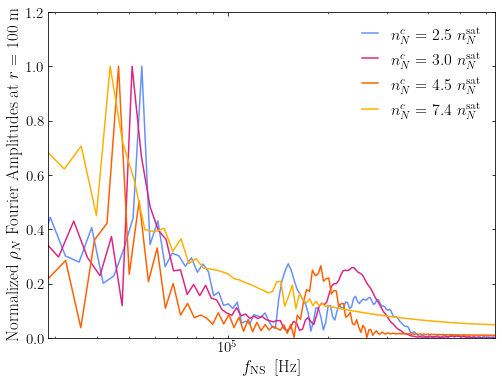

In [41]:
peak_data = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/meta-data/peak_frequency_data.npy")

GeV_2_Hz = 1.51927e+24

labelfontsize = 17
legendfontsize = 16
tickfontsize = 15
mks = 5

AmplitudeSets = []
FrequencySets = []

AmplitudeSetsPeaks = []
FrequencySetsPeaks = []

plot_peaks = []
plot_freqs = []

my_radii = []
my_indices = [45, 90, 180, 270, 360, 450, 540, 630, 720, 810]
#my_indices = [46, 91, 181, 271, 361, 451, 541, 631, 721, 811]

for i in range(len(my_indices)):
    my_radii.append(meta_data_eps1e1_fa1e16[int(my_indices[i]/9), 8])

for i in my_indices:
    Atemp = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/NS-frequency-analysis/nucleon_amplitude_data_" + str(i) + ".npy")
    ftemp = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/NS-frequency-analysis/nucleon_frequency_data_" + str(i) + ".npy")
    AmplitudeSets.append(Atemp)
    FrequencySets.append(ftemp)
    
#     Atemppeak = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/NS-frequency-analysis/nucleon_amplitude_peaks_" + str(i) + ".npy")
#     ftemppeak = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/NS-frequency-analysis/nucleon_frequency_peaks_" + str(i) + ".npy")
#     AmplitudeSetsPeaks.append(Atemppeak)
#     FrequencySetsPeaks.append(ftemppeak)
    
    plot_peaks.append(np.max(Atemp[7:]) / np.max(Atemp[7:]))
    plot_freqs.append(ftemp[np.argmax(Atemp[7:])+7])

    
epsilon_NS = 1e-1
fa_NS = 1e16
mass_NS = beta*np.sqrt(epsilon_NS)*mpi*fpi/(2*fa_NS)

central_densities = np.array([1.7e-03, 2.1e-03, 3.0e-03, 3.7e-03, 4.6e-03, 5.5e-03, 6.4e-03, 7.3e-03, 8.1e-03, 9.0e-03]) / nsatinGeV3
Radii = np.array([5.5e19, 5.2e19, 5.4e19, 5.5e19, 5.5e19, 5.4e19, 5.3e19, 5.1e19])
    
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8, 6), gridspec_kw={'hspace':0.2, 'wspace':0.25})

# index = 1
# ax[0].plot(2*np.pi*FrequencySets[index]*GeV_2_Hz, smooth(AmplitudeSets[index], 1)/np.max(smooth(AmplitudeSets[index][8:], 1)), label=r'$n_N^c = %.01f~n_N^{\rm sat}$' % (central_densities[index]), color=colors[0])
index = 2
ax.plot(FrequencySets[index]*GeV_2_Hz, smooth(AmplitudeSets[index], 1)/np.max(smooth(AmplitudeSets[index][8:], 1)), label=r'$n_N^c = %.01f~n_N^{\rm sat}$' % (central_densities[index]), color=colors[0])
index = 3
ax.plot(FrequencySets[index]*GeV_2_Hz, smooth(AmplitudeSets[index], 1)/np.max(smooth(AmplitudeSets[index][8:], 1)), label=r'$n_N^c = %.01f~n_N^{\rm sat}$' % (central_densities[index]), color=colors[2])
index = 5
ax.plot(FrequencySets[index]*GeV_2_Hz, smooth(AmplitudeSets[index], 1)/np.max(smooth(AmplitudeSets[index][8:], 1)), label=r'$n_N^c = %.01f~n_N^{\rm sat}$' % (central_densities[index]), color=colors[3])
# index =6
# ax[0].plot(2*np.pi*FrequencySets[index]*GeV_2_Hz, smooth(AmplitudeSets[index], 1)/np.max(smooth(AmplitudeSets[index][8:], 1)), label=r'$n_N^c = %.01f~n_N^{\rm sat}$' % (central_densities[index]), color=colors[4])
index = 9
ax.plot(FrequencySets[index]*GeV_2_Hz, smooth(AmplitudeSets[index], 1)/np.max(smooth(AmplitudeSets[index][8:], 1)), label=r'$n_N^c = %.01f~n_N^{\rm sat}$' % (central_densities[index]), color=colors[4])

#ax[0].plot([2*np.pi*plot_freqs[i]*GeV_2_Hz], [plot_peaks[i]], 'o', markersize=mks, color=colors[5])

ax.set_ylabel(r'Normalized $\rho_N$ Fourier Amplitudes at $r = 100~\mathrm{m}$', fontname="serif", fontsize=labelfontsize)
ax.set_xlabel(r'$f_{\rm NS}~\left[\mathrm{Hz}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax.tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax.legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)
#ax[0].set_xlim(3e-17*GeV_2_Hz, 2e-18*GeV_2_Hz)
ax.set_ylim(0, 1.2)
ax.set_xlim(1.8e5/(2*np.pi), 4e6/(2*np.pi))
ax.set_xscale('log')
# ax[0].set_yscale('log')
GeV_2_km / np.array(my_radii)

central_densities_arr = np.linspace(2.2, 7.46, 100)
central_cs = dEOSdrho(NRHO(central_densities_arr*nsatinGeV3))
RadiiFunction = interpol.interp1d(smooth(meta_data_eps1e1_fa1e16[start_TOV:, 0], 2), smooth(meta_data_eps1e1_fa1e16[start_TOV:, 8], 2))
#radii_estimates = RadiiFunction(central_densities_arr*nsatinGeV3)

#estimated_f = (central_cs / (radii_estimates*1e3)) * clight

# ax[1].scatter(np.array([central_densities[2], central_densities[3], central_densities[5], central_densities[9]]), np.array([plot_freqs[2],plot_freqs[3],plot_freqs[5],plot_freqs[9]])*GeV_2_Hz, s=20, facecolors=colors[0], edgecolor=colors[0])
# ax[1].plot(central_densities_arr, estimated_f, '--', color=colors[5])
# #ax[1].scatter(np.array(central_densities), 2*np.pi*np.array(plot_freqs)*GeV_2_Hz, s=20, facecolors=colors[0], edgecolor=colors[0])
# #ax[1].scatter(np.array(my_radii)[2:], 2*np.pi*np.array(plot_freqs[2:])*GeV_2_Hz, s=20, facecolors=colors[4], edgecolor=colors[4])
# #ax[1].scatter(np.array(central_densities[1:]), 2 * np.pi * GeV_2_Hz * 1 / Radii[1:], s=80, facecolors='none', edgecolor=colors[4])
# #ax[1].plot(masses, 2*np.pi*np.array(plot_freqs) / np.array(masses), 'o', markersize=mks, color=colors[0])
# #ax[1].plot([2*np.pi*1e3/(GeV_2_Hz), 2*np.pi*1.3e7/(GeV_2_Hz)], [1.0, 1.0], '--', markersize=mks, color=colors[5])
# ax[1].set_xlabel(r'$n_N^c~\left[n_N^{\mathrm{sat}}\right]$', fontname="serif", fontsize=labelfontsize)
# ax[1].set_ylabel(r'$f_{\rm peak}~\left[\mathrm{Hz}\right]$', fontname="serif", fontsize=labelfontsize)
# ax[1].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
# ax[1].set_yscale('log')
# ax[1].set_ylim(2e4/(2*np.pi), 4e5/(2*np.pi))
# ax[1].set_xlim(2.2, 7.5)
# #ax[1].set_xlim(2*np.pi*1e3/(GeV_2_Hz), 2*np.pi*1.3e7/(GeV_2_Hz))

plt.savefig(plotdirectory + "nucleon-frequencies.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [1227]:
(0.7 / (1e4))*clight

20985.472059999996

# Parameter Space Plot

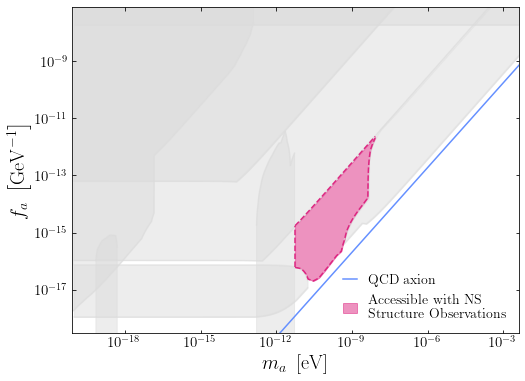

In [165]:
labelfontsize = 20
legendfontsize = 14
tickfontsize = 15
mks = 2

opacity = 0.5
lightlightgrey = (220/255, 220/255, 220/255)

# import constraint data
constraint_directory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/limits/"
pi_lower = np.loadtxt(constraint_directory + "piinsky_lower.csv", delimiter=',')
pi_upper = np.loadtxt(constraint_directory + "piinsky_upper.csv", delimiter=',')
pi_upper[0,0] = pi_lower[0,0]
pi_upper[0,0] = pi_lower[0,0]

in_lower = np.loadtxt(constraint_directory + "inspiral_lower.csv", delimiter=',')
in_upper= np.loadtxt(constraint_directory + "inspiral_upper.csv", delimiter=',')
in_upper[0,0] = in_lower[0,0]
in_upper[0,0] = in_lower[0,0]

lab = np.loadtxt(constraint_directory + "lab.csv", delimiter=',')
SN = np.loadtxt(constraint_directory + "SN.csv", delimiter=',')
SR_1 = np.loadtxt(constraint_directory + "SR_1.csv", delimiter=',')
SR_2 = np.loadtxt(constraint_directory + "SR_2.csv", delimiter=',')
sun = np.loadtxt(constraint_directory + "sun.csv", delimiter=',')
WD = np.loadtxt(constraint_directory + "WD.csv", delimiter=',')

us_lower = np.loadtxt(constraint_directory + "us_lower.csv", delimiter=',')
us_upper = np.loadtxt(constraint_directory + "us_upper.csv", delimiter=',')
us_upper[0,0] = us_lower[0,0]
us_upper[0,0] = us_lower[0,0]

QCD_line = np.loadtxt(constraint_directory + "QCD_line.csv", delimiter=',')

# define constraint interpolation functions
pi_lower_int = interpol.interp1d(pi_lower[:, 0], pi_lower[:, 1], kind='linear', fill_value='extrapolate')
pi_upper_int = interpol.interp1d(pi_upper[:, 0], pi_upper[:, 1], kind='linear', fill_value='extrapolate')

in_lower_int = interpol.interp1d(in_lower[:, 0], in_lower[:, 1], kind='linear', fill_value='extrapolate')
in_upper_int = interpol.interp1d(in_upper[:, 0], in_upper[:, 1], kind='linear', fill_value='extrapolate')

lab_int = interpol.interp1d(lab[:, 0], lab[:, 1], kind='linear', fill_value='extrapolate')
SN_int = interpol.interp1d(SN[:, 0], SN[:, 1], kind='linear', fill_value='extrapolate')
SR1_int = interpol.interp1d(SR_1[:, 0], SR_1[:, 1], kind='linear', fill_value='extrapolate')
SR2_int = interpol.interp1d(SR_2[:, 0], SR_2[:, 1], kind='linear', fill_value='extrapolate')
sun_int = interpol.interp1d(sun[:, 0], sun[:, 1], kind='linear', fill_value='extrapolate')
WD_int = interpol.interp1d(WD[:, 0], WD[:, 1], kind='linear', fill_value='extrapolate')

us_lower_int = interpol.interp1d(us_lower[:, 0], us_lower[:, 1], kind='linear', fill_value='extrapolate')
us_upper_int = interpol.interp1d(us_upper[:, 0], us_upper[:, 1], kind='linear', fill_value='extrapolate')

# define new constraints
Nx = 1000

pi_x = np.logspace(np.log10(pi_upper[0, 0]), np.log10(pi_upper[-1, 0]), Nx)
pi_lower = pi_lower_int(pi_x)
pi_upper = pi_upper_int(pi_x)

in_x = np.logspace(np.log10(in_upper[0, 0]), np.log10(in_upper[-1, 0]), Nx)
in_lower = in_lower_int(in_x)
in_upper = in_upper_int(in_x)

lab_x = np.logspace(np.log10(lab[0, 0]), np.log10(lab[-1, 0]), Nx)
lab = lab_int(lab_x)

SN_x = np.logspace(np.log10(SN[0, 0]), np.log10(SN[-1, 0]), Nx)
SN = SN_int(SN_x)

SR1_x = np.logspace(np.log10(SR_1[0, 0]), np.log10(SR_1[-1, 0]), Nx)
SR1 = SR1_int(SR1_x)

SR2_x = np.logspace(np.log10(SR_2[0, 0]), np.log10(SR_2[-1, 0]), Nx)
SR2 = SR2_int(SR2_x)

sun_x = np.logspace(np.log10(sun[0, 0]), np.log10(sun[-1, 0]), Nx)
sun = sun_int(sun_x)

WD_x = np.logspace(np.log10(WD[0, 0]), np.log10(WD[-1, 0]), Nx)
WD = WD_int(WD_x)

us_x = np.logspace(np.log10(us_upper[0, 0]), np.log10(us_upper[-1, 0]), Nx)
us_lower = us_lower_int(us_x)
us_upper = us_upper_int(us_x)

# make the plots all fancy nice
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8, 6), gridspec_kw={'hspace':0.07, 'wspace':0.15})

ax.plot(pi_x, pi_lower, 'r-', color=lightlightgrey, alpha=opacity)
ax.plot(pi_x, pi_upper, 'r-', color=lightlightgrey, alpha=opacity)
ax.fill_between(pi_x, pi_lower, pi_upper, color=lightlightgrey, alpha=opacity)

ax.plot(in_x, in_lower, 'r-', color=lightlightgrey, alpha=opacity)
ax.plot(in_x, in_upper, 'r-', color=lightlightgrey, alpha=opacity)
ax.fill_between(in_x, in_lower, in_upper, color=lightlightgrey, alpha=opacity)

ax.plot(lab_x, lab, 'r-', color=lightlightgrey, alpha=opacity)
ax.fill_between(lab_x, lab, 1, color=lightlightgrey, alpha=opacity)

ax.plot(SN_x, SN, 'r-', color=lightlightgrey, alpha=opacity)
ax.fill_between(SN_x, SN, 1, color=lightlightgrey, alpha=opacity)

ax.plot(SR1_x, SR1, 'r-', color=lightlightgrey, alpha=opacity)
ax.fill_between(SR1_x, SR1, 0, color=lightlightgrey, alpha=opacity)

ax.plot(SR2_x, SR2, 'r-', color=lightlightgrey, alpha=opacity)
ax.fill_between(SR2_x, SR2, 0, color=lightlightgrey, alpha=opacity)

ax.plot(sun_x, sun , 'r-', color=lightlightgrey, alpha=opacity)
ax.fill_between(sun_x, sun, 1, color=lightlightgrey, alpha=opacity)

ax.plot(WD_x, WD, 'r-', color=lightlightgrey, alpha=opacity)
ax.fill_between(WD_x, WD, 1, color=lightlightgrey, alpha=opacity)

ax.plot(QCD_line[:, 0], QCD_line[:, 1], '-', color=colors[0], label=r'QCD axion')

ax.plot(us_x, us_lower, '--', color=colors[2])
ax.plot([us_x[0], us_x[0]], [us_lower[0], us_upper[0]], '--', color=colors[2])
ax.plot(us_x, us_upper, '--', color=colors[2])
ax.fill_between(us_x, us_lower, us_upper, color=colors[2], alpha=opacity, label='Accessible with NS \n Structure Observations')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$f_a~\left[\mathrm{GeV}^{-1}\right]$', fontname="serif", fontsize=labelfontsize)
ax.set_xlabel(r'$m_a~\left[\mathrm{eV}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax.set_xlim(8e-21, 4e-3)
ax.set_ylim(3e-19, 8e-8)
ax.tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax.legend(frameon=False, fontsize=legendfontsize, loc=4, handlelength=1)

plt.savefig(plotdirectory + "parameter-space.pdf", format="pdf", bbox_inches="tight")

plt.show()



# Friction Test

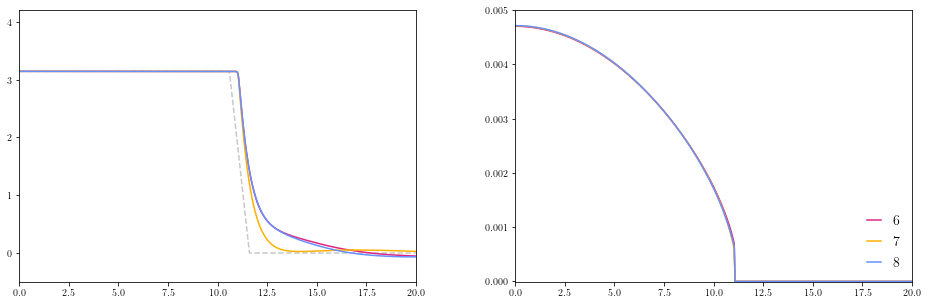

In [937]:
datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/friction-test/"

GeV_2_Hz = 1.51927e+24

labelfontsize = 20
legendfontsize = 14
tickfontsize = 15
mks = 2

Ainit = np.load(datadirectory + "friction_test_8_initial_Avals.npy")
Afin_sets = np.load(datadirectory + "friction_test_8_final_Avals.npy")
nNfin_sets = np.load(datadirectory + "friction_test_8_final_nNvals.npy")
rvals = np.load(datadirectory + "radii.npy")

myindices = [6,7,8]

frictioncolors = [colors[2],colors[4],colors[0],colors[0]]
    
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 5), gridspec_kw={'hspace':0.2, 'wspace':0.25})

ax[0].plot(rvals*GeV_2_km, Ainit, '--', label=r'$a_{\rm init} / f_a$', color=colors[5])
for i in myindices:
    ax[0].plot(rvals*GeV_2_km, Afin_sets[i, :], '-', color=frictioncolors[i%3])
    
for i in myindices:
    ax[1].plot(rvals*GeV_2_km, nNfin_sets[i, :], '-', label=str(i), color=frictioncolors[i%3])

ax[0].set_xlim(0, 20)
ax[1].set_xlim(0, 20)

ax[1].legend(frameon=False, fontsize=legendfontsize, loc=4, handlelength=1)

ax[0].set_ylim(-0.5, 4.2)
ax[1].set_ylim(-1e-5, 5e-3)
#ax[1].set_yscale('log')

plt.show()

479


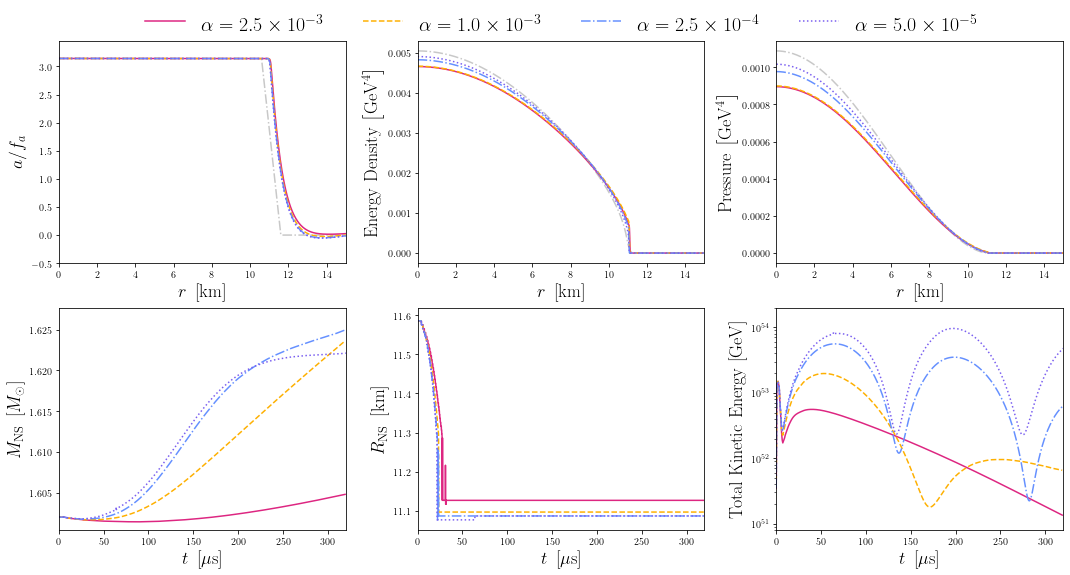

In [988]:
#datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/ic-vs-fs/"
# directory where the dMdt matches dNdt*n is below
#datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/friction-test/animation/data1/"

datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/friction-test/animation/boundary-tests/"
dir1 = datadirectory + 'data1/'
dir2 = datadirectory + 'data2/'
dir3 = datadirectory + 'data3/'
dir4 = datadirectory + 'data4/'

rvals = np.load(dir1 + "radii.npy")
tvals = np.load(dir1 + "times.npy")

Avals1  = np.load(dir1 + "A-solution.npy")
Pvals1  = np.load(dir1 + "P-solution.npy")
Fvals1  = np.load(dir1 + "F-solution.npy")
Gvals1  = np.load(dir1 + "G-solution.npy")
Uvals1  = np.load(dir1 + "U-solution.npy")
nNvals1 = np.load(dir1 + "nN-solution.npy")
NSmasses1 = np.load(dir1 + "NSmasses.npy")
NSradii1  = np.load(dir1 + "NSradii.npy")

Avals2  = np.load(dir2 + "A-solution.npy")
Pvals2  = np.load(dir2 + "P-solution.npy")
Fvals2  = np.load(dir2 + "F-solution.npy")
Gvals2  = np.load(dir2 + "G-solution.npy")
Uvals2  = np.load(dir2 + "U-solution.npy")
nNvals2 = np.load(dir2 + "nN-solution.npy")
NSmasses2 = np.load(dir2 + "NSmasses.npy")
NSradii2  = np.load(dir2 + "NSradii.npy")

Avals3  = np.load(dir3 + "A-solution.npy")
Pvals3  = np.load(dir3 + "P-solution.npy")
Fvals3  = np.load(dir3 + "F-solution.npy")
Gvals3  = np.load(dir3 + "G-solution.npy")
Uvals3  = np.load(dir3 + "U-solution.npy")
nNvals3 = np.load(dir3 + "nN-solution.npy")
NSmasses3 = np.load(dir3 + "NSmasses.npy")
NSradii3  = np.load(dir3 + "NSradii.npy")

Avals4  = np.load(dir4 + "A-solution.npy")
Pvals4  = np.load(dir4 + "P-solution.npy")
Fvals4  = np.load(dir4 + "F-solution.npy")
Gvals4  = np.load(dir4 + "G-solution.npy")
Uvals4  = np.load(dir4 + "U-solution.npy")
nNvals4 = np.load(dir4 + "nN-solution.npy")
NSmasses4 = np.load(dir4 + "NSmasses.npy")
NSradii4  = np.load(dir4 + "NSradii.npy")

final_index_1 = int(len(NSmasses1)/20 - 1)
final_index_2 = int(len(NSmasses2)/20 - 1)
final_index_3 = int(len(NSmasses3)/20 - 1)
final_index_4 = int(len(NSmasses4)/20 - 1)
final_index = min([final_index_1, final_index_2, final_index_3, final_index_4])
end_index = 30

print(final_index)

# Ntot_initial = np.sum(4*np.pi*rvals**2 * Gvals[0,:]*nNvals[0,:] / np.sqrt(1 - Uvals[0,:]**2))
# Ntot_final   = np.sum(4*np.pi*rvals**2 * Gvals[final_index,:]*nNvals[final_index,:] / np.sqrt(1 - Uvals[final_index,:]**2))

epsilon = 1e-3
fa = 1e15

TotalDensityIC  = total_density(rvals, Gvals1[0,:], nNvals1[0,:], Uvals1[0,:], Avals1[0,:], Pvals1[0,:], epsilon, fa)
TotalPressureIC = total_pressure(rvals, Gvals1[0,:], nNvals1[0,:], Uvals1[0,:], Avals1[0,:], Pvals1[0,:], epsilon, fa)

TotalDensity1  = total_density(rvals, Gvals1[final_index,:], nNvals1[final_index,:], Uvals1[final_index,:], Avals1[final_index,:], Pvals1[final_index,:], epsilon, fa)
TotalDensity2  = total_density(rvals, Gvals2[final_index,:], nNvals2[final_index,:], Uvals2[final_index,:], Avals2[final_index,:], Pvals2[final_index,:], epsilon, fa)
TotalDensity3  = total_density(rvals, Gvals3[final_index,:], nNvals3[final_index,:], Uvals3[final_index,:], Avals3[final_index,:], Pvals3[final_index,:], epsilon, fa)
TotalDensity4  = total_density(rvals, Gvals4[final_index,:], nNvals4[final_index,:], Uvals4[final_index,:], Avals4[final_index,:], Pvals4[final_index,:], epsilon, fa)

TotalPressure1 = total_pressure(rvals, Gvals1[final_index,:], nNvals1[final_index,:], Uvals1[final_index,:], Avals1[final_index,:], Pvals1[final_index,:], epsilon, fa)
TotalPressure2 = total_pressure(rvals, Gvals2[final_index,:], nNvals2[final_index,:], Uvals2[final_index,:], Avals2[final_index,:], Pvals2[final_index,:], epsilon, fa)
TotalPressure3 = total_pressure(rvals, Gvals3[final_index,:], nNvals3[final_index,:], Uvals3[final_index,:], Avals3[final_index,:], Pvals3[final_index,:], epsilon, fa)
TotalPressure4 = total_pressure(rvals, Gvals4[final_index,:], nNvals4[final_index,:], Uvals4[final_index,:], Avals4[final_index,:], Pvals4[final_index,:], epsilon, fa)

# get kinetic energy fractions
KE_vals1 = []
KE_vals2 = []
KE_vals3 = []
KE_vals4 = []
for i in range(final_index_1):
    KE_vals1.append(np.sum(4*np.pi*(rvals[1] - rvals[0])*rvals[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii1[i*20]))]**2*kinetic_energy_density(rvals, Gvals1[i,:], nNvals1[i,:], Uvals1[i,:], Avals1[i,:], Pvals1[i,:], epsilon, fa)[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii1[i*20]))]) )#/ NSmasses1[i*20])
for i in range(final_index_2):
    KE_vals2.append(np.sum(4*np.pi*(rvals[1] - rvals[0])*rvals[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii2[i*20]))]**2*kinetic_energy_density(rvals, Gvals2[i,:], nNvals2[i,:], Uvals2[i,:], Avals2[i,:], Pvals2[i,:], epsilon, fa)[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii2[i*20]))]) )#/ NSmasses2[i*20])
for i in range(final_index_3):
    KE_vals3.append(np.sum(4*np.pi*(rvals[1] - rvals[0])*rvals[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii3[i*20]))]**2*kinetic_energy_density(rvals, Gvals3[i,:], nNvals3[i,:], Uvals3[i,:], Avals3[i,:], Pvals3[i,:], epsilon, fa)[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii3[i*20]))]) )#/ NSmasses3[i*20])
for i in range(final_index_4):
    KE_vals4.append(np.sum(4*np.pi*(rvals[1] - rvals[0])*rvals[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii4[i*20]))]**2*kinetic_energy_density(rvals, Gvals4[i,:], nNvals4[i,:], Uvals4[i,:], Avals4[i,:], Pvals4[i,:], epsilon, fa)[:np.argmin(np.abs(rvals - np.ones(np.shape(rvals))*NSradii4[i*20]))]) )#/ NSmasses3[i*20])

# # find the roots of the function
# KEfnc = interpol.interp1d(tvals[0:final_index*20:20], KE_vals)
# zerofnc = lambda t: (KEfnc(t) - 0.01*np.max(KE_vals))
# my_roots = opt.fsolve(zerofnc, [1e18, 1e20, 2e20])

# cutoff_index = np.argmin(np.abs(KE_vals[100:] - 0.01*np.max(KE_vals))) + 100    
# tfin = tvals[cutoff_index*20]*GeV_2_km*10**3 *10**6 / clight
# #print(tfin)

# print(zero_crossings_indices(KE_vals - 0.01*np.max(KE_vals), min_index=0))
# try:
#     tcutindex = np.min(zero_crossings_indices(KE_vals - 0.01*np.max(KE_vals)*np.ones(np.shape(KE_vals)), min_index=0))
# except:
#     tcutindex = 100
# #print(tcut)
# tcut = tvals[20*tcutindex]*GeV_2_km*1e3*1e6/clight
# print(tcut)

labelfontsize = 18
legendfontsize = 20
tickfontsize = 40
mks = 5

maxrad = 15
tend = 320

fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = (18, 9), gridspec_kw={'hspace':0.2, 'wspace':0.25})

ax[0,0].plot(rvals*GeV_2_km, Avals[0, :], '-.', color=colors[5])
ax[0,0].plot(rvals*GeV_2_km, Avals1[final_index, :], '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[0,0].plot(rvals*GeV_2_km, Avals2[final_index, :], '--', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-4}$')
ax[0,0].plot(rvals*GeV_2_km, Avals3[final_index, :], '-.', color=colors[0], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[0,0].plot(rvals*GeV_2_km, Avals4[final_index, :], ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[0,0].set_xlim(0, maxrad)
ax[0,0].set_ylim(-0.5, np.pi*1.1)
ax[0,0].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,0].set_ylabel(r'$a / f_a$ ', fontname="serif", fontsize=labelfontsize)

ax[0,1].plot(rvals*GeV_2_km, TotalDensityIC, '-.', color=colors[5])
ax[0,1].plot(rvals*GeV_2_km, TotalDensity1, '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-3}$')
ax[0,1].plot(rvals*GeV_2_km, TotalDensity2, '--', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-3}$')
ax[0,1].plot(rvals*GeV_2_km, TotalDensity3, '-.', color=colors[0], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[0,1].plot(rvals*GeV_2_km, TotalDensity4, ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[0,1].set_xlim(0, maxrad)
ax[0,1].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,1].set_ylabel(r'Energy Density $\left[\mathrm{GeV}^4\right]$', fontname="serif", fontsize=labelfontsize)
ax[0,1].legend(frameon=False, fontsize=legendfontsize, loc='upper center', bbox_to_anchor=(0.5, 1.2), handlelength=2, ncol=4)

ax[0,2].plot(rvals*GeV_2_km, TotalPressureIC, '-.', color=colors[5])
ax[0,2].plot(rvals*GeV_2_km, TotalPressure1, '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[0,2].plot(rvals*GeV_2_km, TotalPressure2, '--', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-4}$')
ax[0,2].plot(rvals*GeV_2_km, TotalPressure3, '-.', color=colors[0], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[0,2].plot(rvals*GeV_2_km, TotalPressure4, ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[0,2].set_xlim(0, maxrad)
ax[0,2].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,2].set_ylabel(r'Pressure $\left[\mathrm{GeV}^4\right]$', fontname="serif", fontsize=labelfontsize)
#ax[0,2].legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)

ax[1,0].plot(tvals[:len(NSmasses1)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses1[:-end_index]*GeV_2_kg*kg_2_Msun, '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[1,0].plot(tvals[:len(NSmasses2)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses2[:-end_index]*GeV_2_kg*kg_2_Msun, '--', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-4}$')
ax[1,0].plot(tvals[:len(NSmasses3)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses3[:-end_index]*GeV_2_kg*kg_2_Msun, '-.', color=colors[0], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[1,0].plot(tvals[:len(NSmasses4)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses4[:-end_index]*GeV_2_kg*kg_2_Msun, ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[1,0].set_xlim(0, tend)
ax[1,0].set_ylim(NSmasses[0]*0.999*GeV_2_kg*kg_2_Msun, NSmasses[0]*1.016*GeV_2_kg*kg_2_Msun)
ax[1,0].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,0].set_ylabel(r'$M_{\rm NS}~\left[M_{\odot}\right]$ ', fontname="serif", fontsize=labelfontsize)

ax[1,1].plot(tvals[:len(NSmasses1)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii1[:-end_index]*GeV_2_km, '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[1,1].plot(tvals[:len(NSmasses2)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii2[:-end_index]*GeV_2_km, '--', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-4}$')
ax[1,1].plot(tvals[:len(NSmasses3)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii3[:-end_index]*GeV_2_km, '-.', color=colors[0], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[1,1].plot(tvals[:len(NSmasses4)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii4[:-end_index]*GeV_2_km, ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[1,1].set_xlim(0, tend)
ax[1,1].set_ylim(11.05, 11.62)
ax[1,1].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,1].set_ylabel(r'$R_{\rm NS}~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)

ax[1,2].plot(tvals[0:final_index_1*20:20]*GeV_2_km*10**3 *10**6 / clight, KE_vals1, '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[1,2].plot(tvals[0:final_index_2*20:20]*GeV_2_km*10**3 *10**6 / clight, KE_vals2, '--', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-4}$')
ax[1,2].plot(tvals[0:final_index_3*20:20]*GeV_2_km*10**3 *10**6 / clight, KE_vals3, '-.', color=colors[0], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[1,2].plot(tvals[0:final_index_4*20:20]*GeV_2_km*10**3 *10**6 / clight, KE_vals4, ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[1,2].set_yscale('log')
ax[1,2].set_xlim(0.0, tend)
ax[1,2].set_ylim(8e50, 2e54)
ax[1,2].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,2].set_ylabel(r'Total Kinetic Energy $\left[\mathrm{GeV}\right]$', fontname="serif", fontsize=labelfontsize)

plt.savefig(plotdirectory + "friction-test.pdf", format="pdf", bbox_inches="tight")

plt.show()


(236,)
(236,)


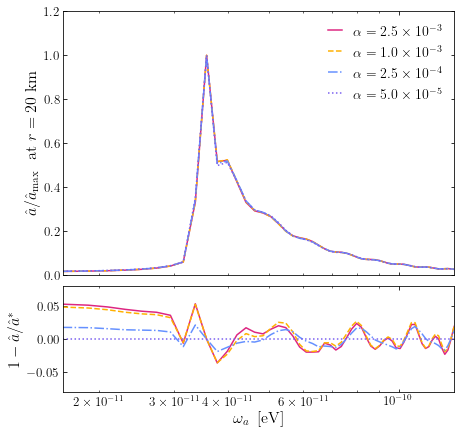

In [27]:
datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/friction-test/"

GeV_2_Hz = 1.51927e+24

labelfontsize = 16
legendfontsize = 14
tickfontsize = 13
mks = 5

AmplitudeSets = []
FrequencySets = []

AmplitudeSetsPeaks = []
FrequencySetsPeaks = []

plot_peaks = []
plot_freqs = []

my_indices = [2,3,4,6]
#my_indices = [46, 91, 181, 271, 361, 451, 541, 631, 721, 811]

# for i in range(len(my_indices)):
#     my_radii.append(meta_data_eps1e1_fa1e16[int(my_indices[i]/9), 8])

for i in my_indices:
    Atemp = np.load(datadirectory + "friction_amplitude_data_" + str(i) + ".npy")
    ftemp = np.load(datadirectory + "friction_frequency_data_" + str(i) + ".npy")
    AmplitudeSets.append(Atemp)
    FrequencySets.append(ftemp)
    
#     Atemppeak = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/NS-frequency-analysis/nucleon_amplitude_peaks_" + str(i) + ".npy")
#     ftemppeak = np.load("/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/NS-frequency-analysis/nucleon_frequency_peaks_" + str(i) + ".npy")
#     AmplitudeSetsPeaks.append(Atemppeak)
#     FrequencySetsPeaks.append(ftemppeak)
    
#     plot_peaks.append(np.max(Atemppeak) / np.max(Atemp[10:]))
#     plot_freqs.append(ftemppeak[np.argmax(Atemppeak)])

    
epsilon_NS = 1e-3
fa_NS = 1e15
mass_NS = beta*np.sqrt(epsilon_NS)*mpi*fpi/(2*fa_NS)

frictions = np.array([])
    
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (7, 7), gridspec_kw={'height_ratios': [5, 2], 'hspace':0.06, 'wspace':0.1})

friction_colors = [colors[2], colors[4], colors[0], colors[1]]

print(np.shape(AmplitudeSets[0]))
print(np.shape(AmplitudeSets[1]))

ax[0].plot(FrequencySets[0]*1e9, smooth(AmplitudeSets[0], 1)/np.max(smooth(AmplitudeSets[0][8:], 1)), '-', label=r'$\alpha = 2.5 \times 10^{-3}$', color=friction_colors[0])
ax[0].plot(FrequencySets[1]*1e9, smooth(AmplitudeSets[1], 1)/np.max(smooth(AmplitudeSets[1][8:], 1)), '--', label=r'$\alpha = 1.0 \times 10^{-3}$', color=friction_colors[1])
ax[0].plot(FrequencySets[2]*1e9, smooth(AmplitudeSets[2], 1)/np.max(smooth(AmplitudeSets[2][8:], 1)), '-.', label=r'$\alpha = 2.5 \times 10^{-4}$', color=friction_colors[2])
ax[0].plot(FrequencySets[3]*1e9, smooth(AmplitudeSets[3], 1)/np.max(smooth(AmplitudeSets[3][8:], 1)), ':', label=r'$\alpha = 5.0 \times 10^{-5}$', color=friction_colors[3])

ax[1].plot(FrequencySets[0]*1e9, np.ones(np.shape(FrequencySets[0])) - (smooth(AmplitudeSets[0], 1)/np.max(smooth(AmplitudeSets[0][8:], 1)))/(smooth(AmplitudeSets[3], 1)/np.max(smooth(AmplitudeSets[3][8:], 1))), '-', label=r'$\alpha = 2.5 \times 10^{-3}$', color=friction_colors[0])
ax[1].plot(FrequencySets[1]*1e9, np.ones(np.shape(FrequencySets[0])) - (smooth(AmplitudeSets[1], 1)/np.max(smooth(AmplitudeSets[1][8:], 1)))/(smooth(AmplitudeSets[3], 1)/np.max(smooth(AmplitudeSets[3][8:], 1))), '--', label=r'$\alpha = 1.0 \times 10^{-3}$', color=friction_colors[1])
ax[1].plot(FrequencySets[2]*1e9, np.ones(np.shape(FrequencySets[0])) - (smooth(AmplitudeSets[2], 1)/np.max(smooth(AmplitudeSets[2][8:], 1)))/(smooth(AmplitudeSets[3], 1)/np.max(smooth(AmplitudeSets[3][8:], 1))), '-.', label=r'$\alpha = 2.5 \times 10^{-4}$', color=friction_colors[2])
ax[1].plot(FrequencySets[3]*1e9, np.ones(np.shape(FrequencySets[0])) - (smooth(AmplitudeSets[3], 1)/np.max(smooth(AmplitudeSets[3][8:], 1)))/(smooth(AmplitudeSets[3], 1)/np.max(smooth(AmplitudeSets[3][8:], 1))), ':', label=r'$\alpha = 5.0 \times 10^{-5}$', color=friction_colors[3])

ax[0].set_ylabel(r'$\hat{a} / \hat{a}_{\rm max} \ \  \mathrm{at} \ r = 20~\mathrm{km}$', fontname="serif", fontsize=labelfontsize)
ax[1].set_ylabel(r'$1 - \hat{a}/ \hat{a}^*$', fontname="serif", fontsize=labelfontsize)
ax[1].set_xlabel(r'$\omega_a~\left[\mathrm{eV}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=False)
ax[1].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax[0].legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)
ax[0].set_xlim(8*np.pi*1e3*1e9/(GeV_2_Hz), 0.5*np.pi*1.3e5*1e9/(GeV_2_Hz))
ax[1].set_xlim(8*np.pi*1e3*1e9/(GeV_2_Hz), 0.5*np.pi*1.3e5*1e9/(GeV_2_Hz))
ax[0].set_ylim(0, 1.2)
ax[1].set_ylim(-0.08, 0.08)
ax[0].set_xscale('log')
ax[1].set_xscale('log')

plt.savefig(plotdirectory + "frequencies-friction.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [942]:
# outward_fluxes = []
# inward_fluxes  = []
# Ntsuccessful = len(NSmasses)

# findex = 300

# Ntotinitial = np.sum(4*np.pi*rvals**2 * nNvals[0,i] * Gvals[0, :] * (rvals[1] - rvals[0]) / np.sqrt(1 - Uvals[0,:]**2))
# Ntotfinal = np.sum(4*np.pi*rvals**2 * nNvals[findex,i] * Gvals[findex, :] * (rvals[1] - rvals[0]) / np.sqrt(1 - Uvals[findex,:]**2))

# for i in range(np.shape(nNvals)[0]):
#     radius_index = 0#int(get_NS_mass_and_radius_from_G0(rvals, nNvals[i,:], nsatinGeV3*1e-5, Gvals[i, :])[2])-1
#     outward_fluxes.append(4*np.pi*rvals[radius_index]**2 * (Uvals[i, radius_index]/(Gvals[i, radius_index]*np.sqrt(1 - Uvals[i,radius_index]**2))**2)*nNvals[i,radius_index])
#     inindex = 0
#     inward_fluxes.append(4*np.pi*rvals[inindex]**2 * (Uvals[i, inindex]/(np.sqrt(1 - Uvals[i,inindex]**2))**2)*nNvals[i,inindex])

# dNSmassesdt = (np.roll(NSmasses, -1, 0) - NSmasses) / (tvals[1]-tvals[0])
# plt.plot(tvals[:len(NSmasses)-end_index]*GeV_2_km*1e3*1e6/clight, abs(dNSmassesdt[:-end_index]), '-', label='dMdt [GeVsquared]')
# # plt.yscale('log')
# # plt.show()

# plt.plot(tvals[:(Ntsuccessful-1):20]*GeV_2_km*1e3*1e6 / clight, abs(np.array(outward_fluxes[:480])*mN), label='out index')
# plt.yscale('log')
# #plt.plot(tvals[:(Ntsuccessful-1):20]*GeV_2_km*1e3*1e6 / clight, inward_fluxes[:486], label='in index')
# plt.legend()
# plt.show()

In [1090]:
print(FrequencySets[0][:10])
print(FrequencySets[1][:10])

[0.00000000e+00 2.05543828e-21 4.11087657e-21 6.16631485e-21
 8.22175313e-21 1.02771914e-20 1.23326297e-20 1.43880680e-20
 1.64435063e-20 1.84989445e-20]
[0.00000000e+00 2.09917101e-21 4.19834202e-21 6.29751304e-21
 8.39668405e-21 1.04958551e-20 1.25950261e-20 1.46941971e-20
 1.67933681e-20 1.88925391e-20]


In [941]:
# nNsmooth = smooth(nNfin_sets[1,:], 20)
# nNHF = nNfin_sets[8,:] - nNsmooth

# plt.plot(rvals, (1.0*np.roll(nNfin_sets[1,:], -1, 0) -2*nNfin_sets[1,:] + 1.0*np.roll(nNfin_sets[1,:], 1, 0)), label='total')
# plt.plot(rvals, (1.0*np.roll(nNHF, -1, 0) -2*nNHF + 1.0*np.roll(nNHF, 1, 0)), label='hf')
# plt.ylim(-1e-7, 1e-7)
# plt.xlim(0, 0.6e20)
# plt.title("abs of second derivative of density")
# plt.show()

# energy loss plots

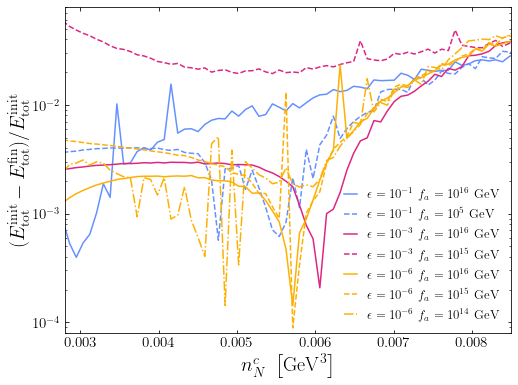

In [197]:
datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/energy-loss/"

labelfontsize = 20
legendfontsize = 13
tickfontsize = 15
mks = 2

start, end = 16, -13

el_eps1_fa16 = np.load(datadirectory + "energy-loss-rates-eps1e-1_fa1e16.npy")
el_eps1_fa15 = np.load(datadirectory + "energy-loss-rates-eps1e-1_fa1e15.npy")

el_eps3_fa16 = np.load(datadirectory + "energy-loss-rates-eps1e-3_fa1e16.npy")
el_eps3_fa15 = np.load(datadirectory + "energy-loss-rates-eps1e-3_fa1e15.npy")

el_eps6_fa16 = np.load(datadirectory + "energy-loss-rates-eps1e-6_fa1e16.npy")
el_eps6_fa15 = np.load(datadirectory + "energy-loss-rates-eps1e-6_fa1e15.npy")
el_eps6_fa14 = np.load(datadirectory + "energy-loss-rates-eps1e-6_fa1e14.npy")


fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8, 6), gridspec_kw={'hspace':0.2, 'wspace':0.25})

ax.plot(el_eps1_fa16[start:end, 0], np.abs((el_eps1_fa16[start:end, 4] - el_eps1_fa16[start:end, 5])/el_eps1_fa16[start:end, 4]), '-', label=r'$\epsilon = 10^{-1} \ f_a = 10^{16}~\mathrm{GeV}$', color=colors[0])
ax.plot(el_eps1_fa15[start:end, 0], np.abs((el_eps1_fa15[start:end, 4] - el_eps1_fa15[start:end, 5])/el_eps1_fa15[start:end, 4]), '--', label=r'$\epsilon = 10^{-1} \ f_a = 10^{5}~\mathrm{GeV}$', color=colors[0])

ax.plot(el_eps3_fa16[start:end, 0], np.abs((el_eps3_fa16[start:end, 4] - el_eps3_fa16[start:end, 5])/el_eps3_fa16[start:end, 4]), '-', label=r'$\epsilon = 10^{-3} \ f_a = 10^{16}~\mathrm{GeV}$', color=colors[2])
ax.plot(el_eps3_fa15[start:end, 0], np.abs((el_eps3_fa15[start:end, 4] - el_eps3_fa15[start:end, 5])/el_eps3_fa15[start:end, 4]), '--', label=r'$\epsilon = 10^{-3} \ f_a = 10^{15}~\mathrm{GeV}$', color=colors[2])

ax.plot(el_eps6_fa16[start:end, 0], np.abs((el_eps6_fa16[start:end, 4] - el_eps6_fa16[start:end, 5])/el_eps6_fa16[start:end, 4]), '-', label=r'$\epsilon = 10^{-6} \ f_a = 10^{16}~\mathrm{GeV}$', color=colors[4])
ax.plot(el_eps6_fa15[start:end, 0], np.abs((el_eps6_fa15[start:end, 4] - el_eps6_fa15[start:end, 5])/el_eps6_fa15[start:end, 4]), '--', label=r'$\epsilon = 10^{-6} \ f_a = 10^{15}~\mathrm{GeV}$', color=colors[4])
ax.plot(el_eps6_fa14[start:end, 0], np.abs((el_eps6_fa14[start:end, 4] - el_eps6_fa14[start:end, 5])/el_eps6_fa14[start:end, 4]), '-.', label=r'$\epsilon = 10^{-6} \ f_a = 10^{14}~\mathrm{GeV}$', color=colors[4])

ax.set_xlim(0.0028, 0.0085)
ax.set_ylim(8e-5, 0.08)

#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$n_N^c~\left[\mathrm{GeV}^{3}\right]$', fontname="serif", fontsize=labelfontsize)
ax.set_ylabel(r'$(E_{\rm tot}^{\rm init} - E_{\rm tot}^{\rm fin}) / E_{\rm tot}^{\rm init}$', fontname="serif", fontsize=labelfontsize)
ax.tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax.legend(frameon=False, fontsize=legendfontsize, loc=4, handlelength=1)

plt.savefig(plotdirectory + "energy-loss.pdf", format="pdf", bbox_inches="tight")

plt.show()


# IC Test

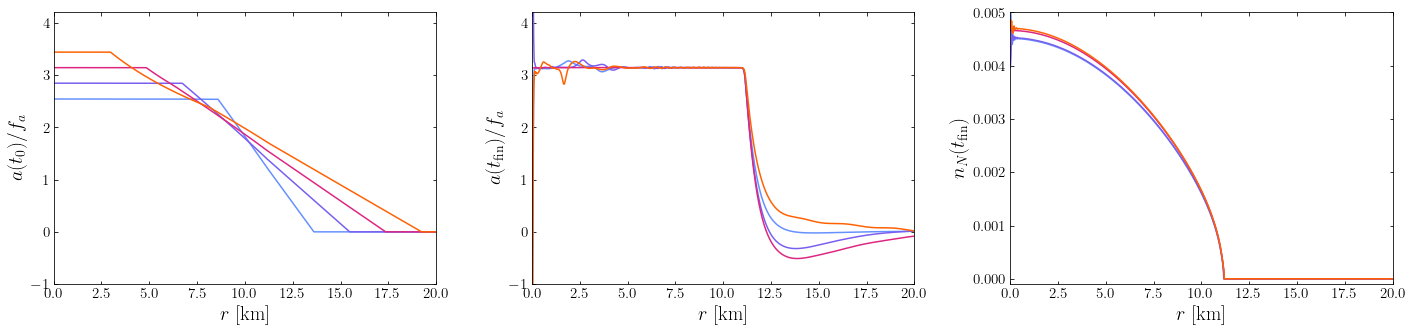

In [265]:
datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/ic-test/"

GeV_2_Hz = 1.51927e+24

labelfontsize = 20
legendfontsize = 14
tickfontsize = 15
mks = 2

Ainit_sets = np.load(datadirectory + "ic_test_2_initial_Avals.npy")
Afin_sets = np.load(datadirectory + "ic_test_2_final_Avals.npy")
nNfin_sets = np.load(datadirectory + "ic_test_2_final_nNvals.npy")
rvals = np.load(datadirectory + "radii.npy")
    
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (24, 5), gridspec_kw={'hspace':0.2, 'wspace':0.25})

myindices = [0, 6, 12, 18]#[0,5,6,10,11,15,16,17,20,21,22,23]

for i in myindices:
    ax[0].plot(rvals*GeV_2_km, Ainit_sets[i, :], color=colors_gradient_8[int(i/3)])
    
for i in myindices:
    ax[1].plot(rvals*GeV_2_km, Afin_sets[i, :], color=colors_gradient_8[int(i/3)])
    
for i in myindices:
    ax[2].plot(rvals*GeV_2_km, nNfin_sets[i, :], color=colors_gradient_8[int(i/3)])

ax[0].set_xlim(0, 20)
ax[1].set_xlim(0, 20)
ax[2].set_xlim(0, 20)

ax[0].set_ylim(-1.0, 4.2)
ax[1].set_ylim(-1.0, 4.2)
ax[2].set_ylim(-1e-4, 5e-3)

ax[0].set_ylabel(r'$a(t_0) / f_a$', fontname="serif", fontsize=labelfontsize)
ax[0].set_xlabel(r'$r~[\mathrm{km}]$', fontname="serif", fontsize=labelfontsize)

ax[1].set_ylabel(r'$a(t_{\rm fin}) / f_a$', fontname="serif", fontsize=labelfontsize)
ax[1].set_xlabel(r'$r~[\mathrm{km}]$', fontname="serif", fontsize=labelfontsize)

ax[2].set_ylabel(r'$n_N(t_{\rm fin})$', fontname="serif", fontsize=labelfontsize)
ax[2].set_xlabel(r'$r~[\mathrm{km}]$', fontname="serif", fontsize=labelfontsize)

ax[0].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax[1].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)
ax[2].tick_params(axis='both', which='both', labelsize=tickfontsize, direction='in', top=True, right=True, labelbottom=True)

plt.savefig(plotdirectory + "ic-test.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [1196]:
meta_data_eps1e1_fa1e16[:,0]

array([0.00122168, 0.00130806, 0.00139444, 0.00148082, 0.0015672 ,
       0.00165358, 0.00173996, 0.00182635, 0.00191273, 0.00199911,
       0.00208549, 0.00217187, 0.00225825, 0.00234463, 0.00243101,
       0.0025174 , 0.00260378, 0.00269016, 0.00277654, 0.00286292,
       0.0029493 , 0.00303568, 0.00312206, 0.00320845, 0.00329483,
       0.00338121, 0.00346759, 0.00355397, 0.00364035, 0.00372673,
       0.00381311, 0.0038995 , 0.00398588, 0.00407226, 0.00415864,
       0.00424502, 0.0043314 , 0.00441778, 0.00450416, 0.00459055,
       0.00467693, 0.00476331, 0.00484969, 0.00493607, 0.00502245,
       0.00510883, 0.00519521, 0.0052816 , 0.00536798, 0.00545436,
       0.00554074, 0.00562712, 0.0057135 , 0.00579988, 0.00588626,
       0.00597264, 0.00605903, 0.00614541, 0.00623179, 0.00631817,
       0.00640455, 0.00649093, 0.00657731, 0.00666369, 0.00675008,
       0.00683646, 0.00692284, 0.00700922, 0.0070956 , 0.00718198,
       0.00726836, 0.00735474, 0.00744113, 0.00752751, 0.00761

In [1201]:
print(meta_data_eps1e1_fa1e16[start_TOV,0] / nsatinGeV3)
print(meta_data_eps1e1_fa1e16[end_TOV,0] / nsatinGeV3)

2.1313131313131315
7.151515151515152


# Resolution Test

(2000, 10000)
(2000, 10000)
(2000, 20000)


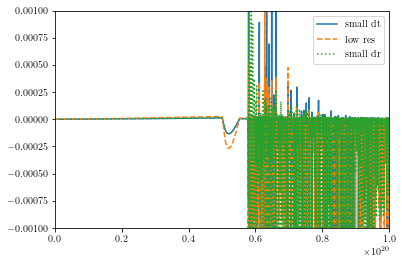

7500
3740
3740


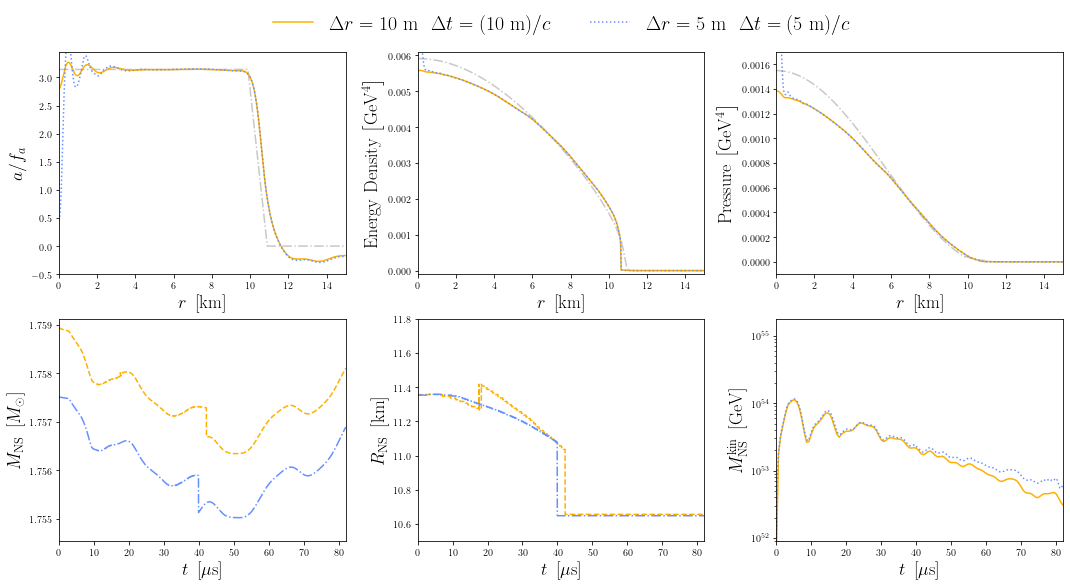

In [31]:
#datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/ic-vs-fs/"
# directory where the dMdt matches dNdt*n is below
#datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/friction-test/animation/data1/"

datadirectory = "/Users/wentmich/Documents/uiuc/research/axions-in-NS/axion-baryon-star-dynamic/cluster-outputs/dtdr-test/"
dir1 = datadirectory + 'hires/'
dir2 = datadirectory + 'lowres/'
dir3 = datadirectory + 'hi_r_res/'

rvals1 = np.load(dir1 + "radii.npy")
tvals1 = np.load(dir1 + "times.npy")

rvals2 = np.load(dir2 + "radii.npy")
tvals2 = np.load(dir2 + "times.npy")

rvals3 = np.load(dir3 + "radii.npy")
tvals3 = np.load(dir3 + "times.npy")

Avals1  = np.load(dir1 + "A-solution.npy")
Pvals1  = np.load(dir1 + "P-solution.npy")
Fvals1  = np.load(dir1 + "F-solution.npy")
Gvals1  = np.load(dir1 + "G-solution.npy")
Uvals1  = np.load(dir1 + "U-solution.npy")
nNvals1 = np.load(dir1 + "nN-solution.npy")
NSmasses1 = np.load(dir1 + "NSmasses.npy")
NSradii1  = np.load(dir1 + "NSradii.npy")

Avals2  = np.load(dir2 + "A-solution.npy")
Pvals2  = np.load(dir2 + "P-solution.npy")
Fvals2  = np.load(dir2 + "F-solution.npy")
Gvals2  = np.load(dir2 + "G-solution.npy")
Uvals2  = np.load(dir2 + "U-solution.npy")
nNvals2 = np.load(dir2 + "nN-solution.npy")
NSmasses2 = np.load(dir2 + "NSmasses.npy")
NSradii2  = np.load(dir2 + "NSradii.npy")

Avals3  = np.load(dir3 + "A-solution.npy")
Pvals3  = np.load(dir3 + "P-solution.npy")
Fvals3  = np.load(dir3 + "F-solution.npy")
Gvals3  = np.load(dir3 + "G-solution.npy")
Uvals3  = np.load(dir3 + "U-solution.npy")
nNvals3 = np.load(dir3 + "nN-solution.npy")
NSmasses3 = np.load(dir3 + "NSmasses.npy")
NSradii3  = np.load(dir3 + "NSradii.npy")

print(np.shape(Avals1))
print(np.shape(Avals2))
print(np.shape(Avals3))

# plt.plot(rvals1, Avals1[0, :])
# plt.plot(rvals2, Avals2[0, :])
# plt.plot(rvals3, Avals3[0, :])
# plt.xlim(0,1e20)
# plt.show()

# plt.plot(rvals1, nNvals1[0, :])
# plt.plot(rvals2, nNvals2[0, :])
# plt.plot(rvals3, nNvals3[0, :])
# plt.xlim(0,1e20)
# plt.show()

plt.plot(rvals1, Uvals1[0, :], '-', label='small dt')
plt.plot(rvals2, Uvals2[0, :], '--', label='low res')
plt.plot(rvals3, Uvals3[0, :], ':', label='small dr')
plt.xlim(0,1e20)
plt.ylim(-0.001,0.001)
plt.legend()
plt.show()

# plt.plot(rvals1, Pvals1[0, :])
# plt.plot(rvals2, Pvals2[0, :])
# plt.plot(rvals3, Pvals3[0, :])
# plt.xlim(0,1e20)
# plt.show()

# plt.plot(rvals1, Fvals1[0, :])
# plt.plot(rvals2, Fvals2[0, :])
# plt.plot(rvals3, Fvals3[0, :])
# plt.xlim(0,1e20)
# plt.show()

# plt.plot(rvals1, Gvals1[0, :])
# plt.plot(rvals2, Gvals2[0, :])
# plt.plot(rvals3, Gvals3[0, :])
# plt.xlim(0,1e20)
# plt.show()


final_index_1 = int(len(NSmasses1)/20 - 1) - 60
final_index_2 = int(len(NSmasses2)/20 - 1)
end_index = 30

final_index_2 = int(final_index_1/2)
final_index_3 = int(final_index_1/2)

print(final_index_1*20)
print(final_index_2*20)
print(final_index_3*20)

steps = 5020
final_index_1 = int(steps/2 / 20)
final_index_2 = int(steps/2 / 20)#int(steps/20)
final_index_3 = int(steps / 20)#int(steps/20 * 2)

# Ntot_initial = np.sum(4*np.pi*rvals**2 * Gvals[0,:]*nNvals[0,:] / np.sqrt(1 - Uvals[0,:]**2))
# Ntot_final   = np.sum(4*np.pi*rvals**2 * Gvals[final_index,:]*nNvals[final_index,:] / np.sqrt(1 - Uvals[final_index,:]**2))

epsilon = 1e-1
fa = 1e16

TotalDensityIC  = total_density(rvals1, Gvals1[0,:], nNvals1[0,:], Uvals1[0,:], Avals1[0,:], Pvals1[0,:], epsilon, fa)
TotalPressureIC = total_pressure(rvals1, Gvals1[0,:], nNvals1[0,:], Uvals1[0,:], Avals1[0,:], Pvals1[0,:], epsilon, fa)

TotalDensity1  = total_density(rvals1, Gvals1[final_index_1,:], nNvals1[final_index_1,:], Uvals1[final_index_1,:], Avals1[final_index_1,:], Pvals1[final_index_1,:], epsilon, fa)
TotalDensity2  = total_density(rvals2, Gvals2[final_index_2,:], nNvals2[final_index_2,:], Uvals2[final_index_2,:], Avals2[final_index_2,:], Pvals2[final_index_2,:], epsilon, fa)
TotalDensity3  = total_density(rvals3, Gvals3[final_index_3,:], nNvals3[final_index_3,:], Uvals3[final_index_3,:], Avals3[final_index_3,:], Pvals3[final_index_3,:], epsilon, fa)

TotalPressure1 = total_pressure(rvals1, Gvals1[final_index_1,:], nNvals1[final_index_1,:], Uvals1[final_index_1,:], Avals1[final_index_1,:], Pvals1[final_index_1,:], epsilon, fa)
TotalPressure2 = total_pressure(rvals2, Gvals2[final_index_2,:], nNvals2[final_index_2,:], Uvals2[final_index_2,:], Avals2[final_index_2,:], Pvals2[final_index_2,:], epsilon, fa)
TotalPressure3 = total_pressure(rvals3, Gvals3[final_index_3,:], nNvals3[final_index_3,:], Uvals3[final_index_3,:], Avals3[final_index_3,:], Pvals3[final_index_3,:], epsilon, fa)

# get kinetic energy fractions
KE_vals1 = []
KE_vals2 = []
KE_vals3 = []
KE_vals4 = []
for i in range(final_index_1):
    KE_vals1.append(np.sum(4*np.pi*(rvals1[1] - rvals1[0])*rvals1[:np.argmin(np.abs(rvals1 - np.ones(np.shape(rvals1))*NSradii1[i*20]))]**2*kinetic_energy_density(rvals1, Gvals1[i,:], nNvals1[i,:], Uvals1[i,:], Avals1[i,:], Pvals1[i,:], epsilon, fa)[:np.argmin(np.abs(rvals1 - np.ones(np.shape(rvals1))*NSradii1[i*20]))]) )#/ NSmasses1[i*20])
for i in range(final_index_2):
    KE_vals2.append(np.sum(4*np.pi*(rvals2[1] - rvals2[0])*rvals2[:np.argmin(np.abs(rvals2 - np.ones(np.shape(rvals2))*NSradii2[i*20]))]**2*kinetic_energy_density(rvals2, Gvals2[i,:], nNvals2[i,:], Uvals2[i,:], Avals2[i,:], Pvals2[i,:], epsilon, fa)[:np.argmin(np.abs(rvals2 - np.ones(np.shape(rvals2))*NSradii2[i*20]))]) )#/ NSmasses2[i*20])
for i in range(final_index_3):
    KE_vals3.append(np.sum(4*np.pi*(rvals3[1] - rvals3[0])*rvals3[:np.argmin(np.abs(rvals3 - np.ones(np.shape(rvals3))*NSradii3[i*20]))]**2*kinetic_energy_density(rvals3, Gvals3[i,:], nNvals3[i,:], Uvals3[i,:], Avals3[i,:], Pvals3[i,:], epsilon, fa)[:np.argmin(np.abs(rvals3 - np.ones(np.shape(rvals3))*NSradii3[i*20]))]) )#/ NSmasses2[i*20])

# # find the roots of the function
# KEfnc = interpol.interp1d(tvals[0:final_index*20:20], KE_vals)
# zerofnc = lambda t: (KEfnc(t) - 0.01*np.max(KE_vals))
# my_roots = opt.fsolve(zerofnc, [1e18, 1e20, 2e20])

# cutoff_index = np.argmin(np.abs(KE_vals[100:] - 0.01*np.max(KE_vals))) + 100    
# tfin = tvals[cutoff_index*20]*GeV_2_km*10**3 *10**6 / clight
# #print(tfin)

# print(zero_crossings_indices(KE_vals - 0.01*np.max(KE_vals), min_index=0))
# try:
#     tcutindex = np.min(zero_crossings_indices(KE_vals - 0.01*np.max(KE_vals)*np.ones(np.shape(KE_vals)), min_index=0))
# except:
#     tcutindex = 100
# #print(tcut)
# tcut = tvals[20*tcutindex]*GeV_2_km*1e3*1e6/clight
# print(tcut)

labelfontsize = 18
legendfontsize = 20
tickfontsize = 40
mks = 5

maxrad = 15
tend = 82

fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = (18, 9), gridspec_kw={'hspace':0.2, 'wspace':0.25})

ax[0,0].plot(rvals2*GeV_2_km, Avals2[0, :], '-.', color=colors[5])
#ax[0,0].plot(rvals3*GeV_2_km, Avals3[0, :], '-.', color=colors[6])
#ax[0,0].plot(rvals1*GeV_2_km, Avals1[final_index_1, :], '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[0,0].plot(rvals2*GeV_2_km, Avals2[final_index_2, :], '-', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-4}$')
ax[0,0].plot(rvals3*GeV_2_km, Avals3[final_index_3, :], ':', color=colors[0], label=r'$\alpha = 1.0 \times 10^{-4}$')
# ax[0,0].plot(rvals*GeV_2_km, Avals3[final_index, :], '-.', color=colors[0], label=r'$\alpha = 5.0 \times 10^{-5}$')
# ax[0,0].plot(rvals*GeV_2_km, Avals4[final_index, :], ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[0,0].set_xlim(0, maxrad)
ax[0,0].set_ylim(-0.5, np.pi*1.1)
ax[0,0].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,0].set_ylabel(r'$a / f_a$ ', fontname="serif", fontsize=labelfontsize)

ax[0,1].plot(rvals1*GeV_2_km, TotalDensityIC, '-.', color=colors[5])
#ax[0,1].plot(rvals1*GeV_2_km, TotalDensity1, '-', color=colors[2], label=r'$\Delta t = \Delta r$')
ax[0,1].plot(rvals2*GeV_2_km, TotalDensity2, '-', color=colors[4], label=r'$\Delta r = 10~\mathrm{m} \ \ \Delta t = (10~\mathrm{m}) / c$')
ax[0,1].plot(rvals3*GeV_2_km, TotalDensity3, ':', color=colors[0], label=r'$\Delta r = 5~\mathrm{m} \ \ \Delta t = (5~\mathrm{m}) / c$')
# ax[0,1].plot(rvals*GeV_2_km, TotalDensity3, '-.', color=colors[0], label=r'$\alpha = 2.5 \times 10^{-4}$')
# ax[0,1].plot(rvals*GeV_2_km, TotalDensity4, ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[0,1].set_xlim(0, maxrad)
ax[0,1].set_ylim(-1e-4, 6.1e-3)
ax[0,1].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,1].set_ylabel(r'Energy Density $\left[\mathrm{GeV}^4\right]$', fontname="serif", fontsize=labelfontsize)
ax[0,1].legend(frameon=False, fontsize=legendfontsize, loc='upper center', bbox_to_anchor=(0.5, 1.25), handlelength=2, ncol=4)

ax[0,2].plot(rvals1*GeV_2_km, TotalPressureIC, '-.', color=colors[5])
#ax[0,2].plot(rvals1*GeV_2_km, TotalPressure1, '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[0,2].plot(rvals2*GeV_2_km, TotalPressure2, '-', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-4}$')
ax[0,2].plot(rvals3*GeV_2_km, TotalPressure3, ':', color=colors[0], label=r'$\alpha = 1.0 \times 10^{-4}$')
# ax[0,2].plot(rvals*GeV_2_km, TotalPressure3, '-.', color=colors[0], label=r'$\alpha = 5.0 \times 10^{-5}$')
# ax[0,2].plot(rvals*GeV_2_km, TotalPressure4, ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[0,2].set_xlim(0, maxrad)
ax[0,2].set_ylim(-1e-4, 1.7e-3)
ax[0,2].set_xlabel(r'$r~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[0,2].set_ylabel(r'Pressure $\left[\mathrm{GeV}^4\right]$', fontname="serif", fontsize=labelfontsize)
#ax[0,2].legend(frameon=False, fontsize=legendfontsize, loc=1, handlelength=1)

#ax[1,0].plot(tvals1[:len(NSmasses1)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses1[:-end_index]*GeV_2_kg*kg_2_Msun, '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[1,0].plot(tvals2[:len(NSmasses2)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses2[:-end_index]*GeV_2_kg*kg_2_Msun, '--', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-4}$')
ax[1,0].plot(tvals3[:len(NSmasses3)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses3[:-end_index]*GeV_2_kg*kg_2_Msun, '-.', color=colors[0], label=r'$\alpha = 1.0 \times 10^{-4}$')
# ax[1,0].plot(tvals[:len(NSmasses3)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses3[:-end_index]*GeV_2_kg*kg_2_Msun, '-.', color=colors[0], label=r'$\alpha = 5.0 \times 10^{-5}$')
# ax[1,0].plot(tvals[:len(NSmasses4)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSmasses4[:-end_index]*GeV_2_kg*kg_2_Msun, ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[1,0].set_xlim(0, tend)
ax[1,0].set_ylim(NSmasses1[0]*0.9975*GeV_2_kg*kg_2_Msun, NSmasses1[0]*1.0001*GeV_2_kg*kg_2_Msun)
ax[1,0].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,0].set_ylabel(r'$M_{\rm NS}~\left[M_{\odot}\right]$ ', fontname="serif", fontsize=labelfontsize)

#ax[1,1].plot(tvals1[:len(NSmasses1)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii1[:-end_index]*GeV_2_km, '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[1,1].plot(tvals2[:len(NSmasses2)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii2[:-end_index]*GeV_2_km, '--', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-4}$')
ax[1,1].plot(tvals3[:len(NSmasses3)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii3[:-end_index]*GeV_2_km, '-.', color=colors[0], label=r'$\alpha = 1.0 \times 10^{-4}$')
# ax[1,1].plot(tvals[:len(NSmasses3)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii3[:-end_index]*GeV_2_km, '-.', color=colors[0], label=r'$\alpha = 5.0 \times 10^{-5}$')
# ax[1,1].plot(tvals[:len(NSmasses4)-end_index]*GeV_2_km*10**3 *10**6 / clight, NSradii4[:-end_index]*GeV_2_km, ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[1,1].set_xlim(0, tend)
ax[1,1].set_ylim(10.5, 11.8)
ax[1,1].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,1].set_ylabel(r'$R_{\rm NS}~\left[\mathrm{km}\right]$ ', fontname="serif", fontsize=labelfontsize)

#ax[1,2].plot(tvals1[0:final_index_1*20:20]*GeV_2_km*10**3 *10**6 / clight, KE_vals1, '-', color=colors[2], label=r'$\alpha = 2.5 \times 10^{-4}$')
ax[1,2].plot(tvals2[0:final_index_2*20:20]*GeV_2_km*10**3 *10**6 / clight, KE_vals2, '-', color=colors[4], label=r'$\alpha = 1.0 \times 10^{-4}$')
ax[1,2].plot(tvals3[0:final_index_3*20:20]*GeV_2_km*10**3 *10**6 / clight, KE_vals3, ':', color=colors[0], label=r'$\alpha = 1.0 \times 10^{-4}$')
# ax[1,2].plot(tvals[0:final_index_3*20:20]*GeV_2_km*10**3 *10**6 / clight, KE_vals3, '-.', color=colors[0], label=r'$\alpha = 5.0 \times 10^{-5}$')
# ax[1,2].plot(tvals[0:final_index_4*20:20]*GeV_2_km*10**3 *10**6 / clight, KE_vals4, ':', color=colors[1], label=r'$\alpha = 5.0 \times 10^{-5}$')
ax[1,2].set_yscale('log')
ax[1,2].set_xlim(0.0, tend)
ax[1,2].set_ylim(90e50, 18e54)
ax[1,2].set_xlabel(r'$t~\left[\mu\mathrm{s}\right]$ ', fontname="serif", fontsize=labelfontsize)
ax[1,2].set_ylabel(r'$M_{\rm NS}^{\rm kin}~\left[\mathrm{GeV}\right]$', fontname="serif", fontsize=labelfontsize)

plt.savefig(plotdirectory + "resolution-test.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [11]:
print(len(NSmasses2))
print(len(NSmasses3))

9001
8961


In [32]:
0.00554 / nsatinGeV3

4.5347487494233265